# Predictive Maintenance: 24-Hour Failure Forecasting

**Objective:** Predict machine failures 24 hours in advance for 100 machines using the Azure Predictive Maintenance dataset.

**Approach:** Binary classification with LightGBM, features justified by statistical EDA, 3-way temporal split (train/val/test).

**Repository:**
- `src/features.py` feature engineering (tested, with leakage guards)
- `src/utils.py` evaluation metrics and helpers
- `tests/test_features.py` 9 tests covering label boundaries and leakage prevention

**Environment:** `uv sync`

In [1]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
import seaborn as sns
import shap
from lightgbm import LGBMClassifier
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

from src.features import (
    build_feature_matrix,
    compute_labels,
    compute_telemetry_features,
    compute_vif_screening,
)
from src.utils import (
    bootstrap_ci,
    compute_pearson_residuals,
    download_datasets,
    event_level_recall,
    set_plot_style,
)

SEED: int = 42
SEEDS: list[int] = [42, 123, 456, 789, 1024]
DATA_DIR: Path = Path("../data")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

set_plot_style()
np.random.seed(SEED)

NOTEBOOK_START: float = time.time()
section_times: dict[str, float] = {}

/Users/enriquediazdeleonhicks/repositories/jobs-2026/quadsci/telemetry-assessment/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1: Data Loading & Verification

In [2]:
section_start: float = time.time()

telemetry: pd.DataFrame = pd.read_csv(DATA_DIR / "PdM_telemetry.csv", parse_dates=["datetime"])
errors: pd.DataFrame = pd.read_csv(DATA_DIR / "PdM_errors.csv", parse_dates=["datetime"])
maint: pd.DataFrame = pd.read_csv(DATA_DIR / "PdM_maint.csv", parse_dates=["datetime"])
failures: pd.DataFrame = pd.read_csv(DATA_DIR / "PdM_failures.csv", parse_dates=["datetime"])
machines: pd.DataFrame = pd.read_csv(DATA_DIR / "PdM_machines.csv")

datasets: dict[str, pd.DataFrame] = {
    "telemetry": telemetry, "errors": errors, "maint": maint,
    "failures": failures, "machines": machines,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")
    print(f"  dtypes: {dict(df.dtypes)}")
    if "datetime" in df.columns:
        print(f"  period: {df['datetime'].min()} to {df['datetime'].max()}")
    print()

# Duplicate check
tel_dupes: int = int(telemetry.duplicated(subset=["datetime", "machineID"]).sum())
err_dupes: int = int(errors.duplicated(subset=["datetime", "machineID", "errorID"]).sum())
fail_dupes: int = int(failures.duplicated(subset=["datetime", "machineID"]).sum())
print(f"Duplicates: telemetry={tel_dupes}, errors={err_dupes}, failures={fail_dupes}")
assert tel_dupes == 0, f"Telemetry has {tel_dupes} duplicate rows"
if fail_dupes > 0:
    print(f"  Note: {fail_dupes} failure duplicates = multiple components failing at same hour.")

# Machine coverage
tel_machines: set[int] = set(telemetry["machineID"].unique())
fail_machines: set[int] = set(failures["machineID"].unique())
all_machines: set[int] = set(machines["machineID"].unique())
fail_without_tel: set[int] = fail_machines - tel_machines
assert len(fail_without_tel) == 0, f"Machines with failures but no telemetry: {fail_without_tel}"
print(f"Machine coverage: {len(tel_machines)} in telemetry, {len(fail_machines)} with failures")
print(f"  Machines that never failed: {all_machines - fail_machines}")

# Failure-maintenance consistency
matched: int = 0
for _, fail in failures.iterrows():
    has_maint: bool = bool(maint[
        (maint["machineID"] == fail["machineID"])
        & (maint["datetime"] == fail["datetime"])
        & (maint["comp"] == fail["failure"])
    ].shape[0] > 0)
    matched += int(has_maint)
print(f"Failure-maintenance match: {matched}/{len(failures)} ({matched/len(failures)*100:.1f}%)")

# Telemetry sampling frequency
diffs: pd.Series = (
    telemetry.sort_values(["machineID", "datetime"])
    .groupby("machineID")["datetime"].diff()
)
sampling_interval: pd.Timedelta = diffs.mode().iloc[0]
non_null_diffs: pd.Series = diffs.dropna()
n_exactly_1h: int = int((non_null_diffs == pd.Timedelta(hours=1)).sum())
n_irregular: int = len(non_null_diffs) - n_exactly_1h

assert sampling_interval == pd.Timedelta(hours=1), f"Expected hourly, got {sampling_interval}"
assert n_irregular == 0, f"{n_irregular} irregular intervals found"
print(f"Sampling: {sampling_interval}, 100% regular, no gaps.")

section_times["1_data_loading"] = time.time() - section_start
print(f"\nSection 1: {section_times['1_data_loading']:.1f}s")

telemetry: (876100, 6)
  dtypes: {'datetime': dtype('<M8[us]'), 'machineID': dtype('int64'), 'volt': dtype('float64'), 'rotate': dtype('float64'), 'pressure': dtype('float64'), 'vibration': dtype('float64')}
  period: 2015-01-01 06:00:00 to 2016-01-01 06:00:00

errors: (3919, 3)
  dtypes: {'datetime': dtype('<M8[us]'), 'machineID': dtype('int64'), 'errorID': <StringDtype(na_value=nan)>}
  period: 2015-01-01 06:00:00 to 2016-01-01 05:00:00

maint: (3286, 3)
  dtypes: {'datetime': dtype('<M8[us]'), 'machineID': dtype('int64'), 'comp': <StringDtype(na_value=nan)>}
  period: 2014-06-01 06:00:00 to 2016-01-01 06:00:00

failures: (761, 3)
  dtypes: {'datetime': dtype('<M8[us]'), 'machineID': dtype('int64'), 'failure': <StringDtype(na_value=nan)>}
  period: 2015-01-02 03:00:00 to 2015-12-31 06:00:00

machines: (100, 3)
  dtypes: {'machineID': dtype('int64'), 'model': <StringDtype(na_value=nan)>, 'age': dtype('int64')}

Duplicates: telemetry=0, errors=0, failures=42
  Note: 42 failure duplicat

## Section 2: Exploratory Data Analysis

In [3]:
section_start = time.time()

# Null analysis
for name, df in datasets.items():
    nulls: pd.Series = df.isnull().sum()
    total: int = len(df)
    if nulls.any():
        for col, count in nulls[nulls > 0].items():
            print(f"  {name}.{col}: {count}/{total} ({count/total*100:.2f}%)")
    else:
        print(f"  {name}: no nulls")

print()
telemetry[["volt", "rotate", "pressure", "vibration"]].describe().round(2)

  telemetry: no nulls
  errors: no nulls
  maint: no nulls
  failures: no nulls
  machines: no nulls



,volt,rotate,pressure,vibration
count,876100.00,876100.00,876100.00,876100.00
mean,170.78,446.61,100.86,40.39
std,15.51,52.67,11.05,5.37
min,97.33,138.43,51.24,14.88
25%,160.30,412.31,93.50,36.78
50%,170.61,447.56,100.43,40.24
75%,181.00,482.18,107.56,43.78
max,255.12,695.02,185.95,76.79


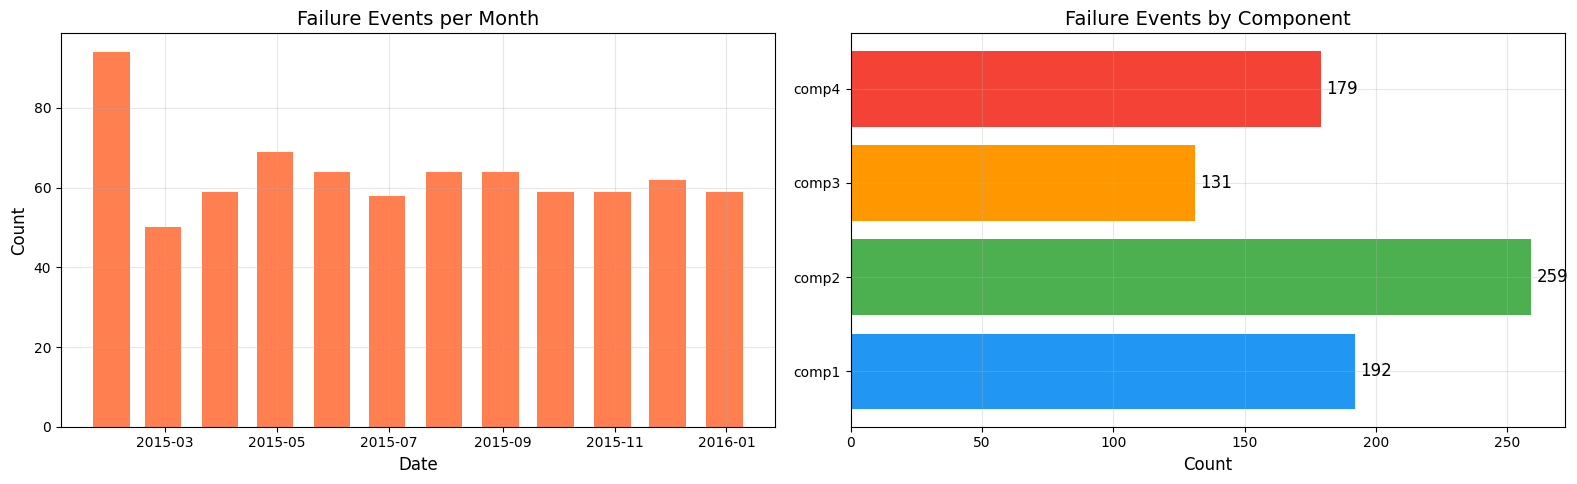

Total failures: 761, across 98/100 machines
Mean per machine: 7.8


In [4]:
failures_monthly: pd.Series = failures.set_index("datetime").resample("ME")["machineID"].count()
fail_counts: pd.Series = failures["failure"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(failures_monthly.index, failures_monthly.values, width=20, color="coral")
axes[0].set_title("Failure Events per Month")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")

axes[1].barh(fail_counts.index, fail_counts.values, color=["#2196F3", "#4CAF50", "#FF9800", "#F44336"])
axes[1].set_title("Failure Events by Component")
axes[1].set_xlabel("Count")
for i, v in enumerate(fail_counts.values):
    axes[1].text(v + 2, i, str(v), va="center")
plt.tight_layout()
plt.show()

print(f"Total failures: {len(failures)}, across {failures['machineID'].nunique()}/100 machines")
print(f"Mean per machine: {failures.groupby('machineID').size().mean():.1f}")

In [5]:
# Class distribution for 24h prediction window
positive_mask: pd.Series = pd.Series(False, index=telemetry.index)

for _, fail in failures.iterrows():
    mask: pd.Series = (
        (telemetry["machineID"] == fail["machineID"])
        & (telemetry["datetime"] >= fail["datetime"] - pd.Timedelta(hours=24))
        & (telemetry["datetime"] < fail["datetime"])  # excludes failure timestamp
    )
    positive_mask = positive_mask | mask

n_positive: int = int(positive_mask.sum())
n_total: int = len(telemetry)
positive_rate: float = n_positive / n_total

print(f"Positive (failure within 24h): {n_positive:,} ({positive_rate*100:.2f}%)")
print(f"Negative:                      {n_total - n_positive:,} ({(1-positive_rate)*100:.2f}%)")
print(f"Imbalance ratio:               1:{int(1/positive_rate)}")
print(f"Records per failure event:     {n_positive/len(failures):.1f} (expected ~24)")

Positive (failure within 24h): 17,184 (1.96%)
Negative:                      858,916 (98.04%)
Imbalance ratio:               1:50
Records per failure event:     22.6 (expected ~24)


### 2.2 Telemetry Signal Analysis

Stationarity, autocorrelation structure, and distributional differences between normal and pre-failure periods.

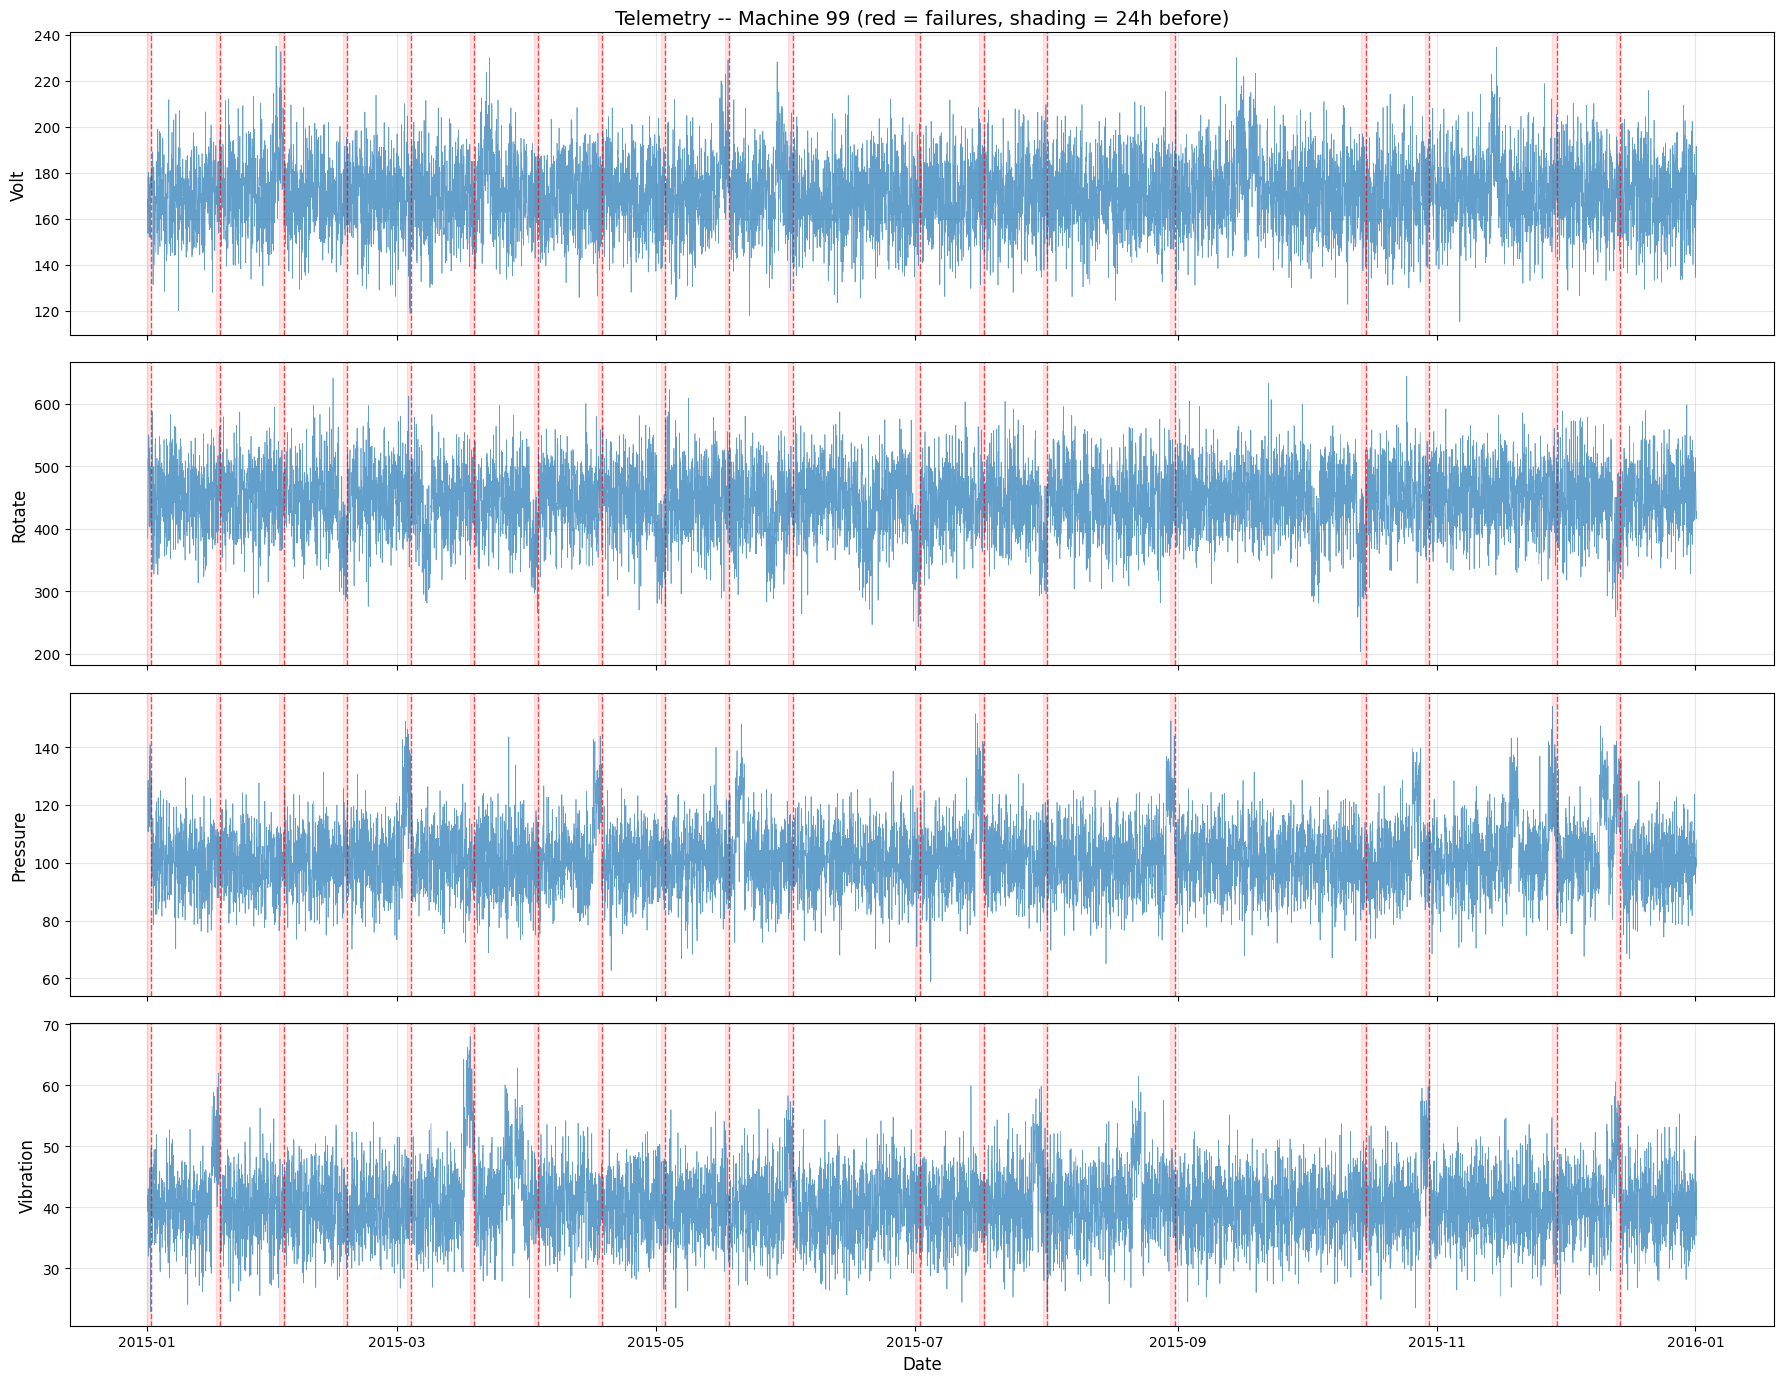

In [6]:
sensors: list[str] = ["volt", "rotate", "pressure", "vibration"]

fail_counts_per_machine: pd.Series = failures.groupby("machineID").size().sort_values(ascending=False)
example_machine: int = int(fail_counts_per_machine.index[0])
machine_failures: pd.DataFrame = failures[failures["machineID"] == example_machine].sort_values("datetime")
machine_telemetry: pd.DataFrame = telemetry[telemetry["machineID"] == example_machine].sort_values("datetime")

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
for i, sensor in enumerate(sensors):
    ax: plt.Axes = axes[i]
    ax.plot(machine_telemetry["datetime"], machine_telemetry[sensor], linewidth=0.5, alpha=0.7)
    ax.set_ylabel(sensor.capitalize())
    for _, fail in machine_failures.iterrows():
        ax.axvline(fail["datetime"], color="red", linestyle="--", alpha=0.7, linewidth=1)
        ax.axvspan(fail["datetime"] - pd.Timedelta(hours=24), fail["datetime"], color="red", alpha=0.1)

axes[0].set_title(f"Telemetry -- Machine {example_machine} (red = failures, shading = 24h before)")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [7]:
# Stationarity: ADF (H0=non-stationary) + KPSS (H0=stationary)
sample_machines: list[int] = sorted(telemetry["machineID"].unique())[:5]

for sensor in sensors:
    adf_pvals: list[float] = []
    kpss_pvals: list[float] = []
    for machine_id in sample_machines:
        series: pd.Series = telemetry[telemetry["machineID"] == machine_id][sensor].dropna()
        adf_pvals.append(float(adfuller(series, autolag="AIC")[1]))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_pvals.append(float(kpss(series, regression="ct", nlags="auto")[1]))

    adf_p: float = float(np.mean(adf_pvals))
    kpss_p: float = float(np.mean(kpss_pvals))
    print(f"{sensor:12s} | ADF p={adf_p:.6f} ({'stationary' if adf_p < 0.05 else 'non-stationary'}) "
          f"| KPSS p={kpss_p:.4f} ({'stationary' if kpss_p >= 0.05 else 'non-stationary'})")

volt         | ADF p=0.000000 (stationary) | KPSS p=0.0948 (stationary)
rotate       | ADF p=0.000000 (stationary) | KPSS p=0.0782 (stationary)
pressure     | ADF p=0.000000 (stationary) | KPSS p=0.0841 (stationary)
vibration    | ADF p=0.000000 (stationary) | KPSS p=0.0993 (stationary)


All sensors stationary. Raw rolling stats are appropriate, no differencing needed

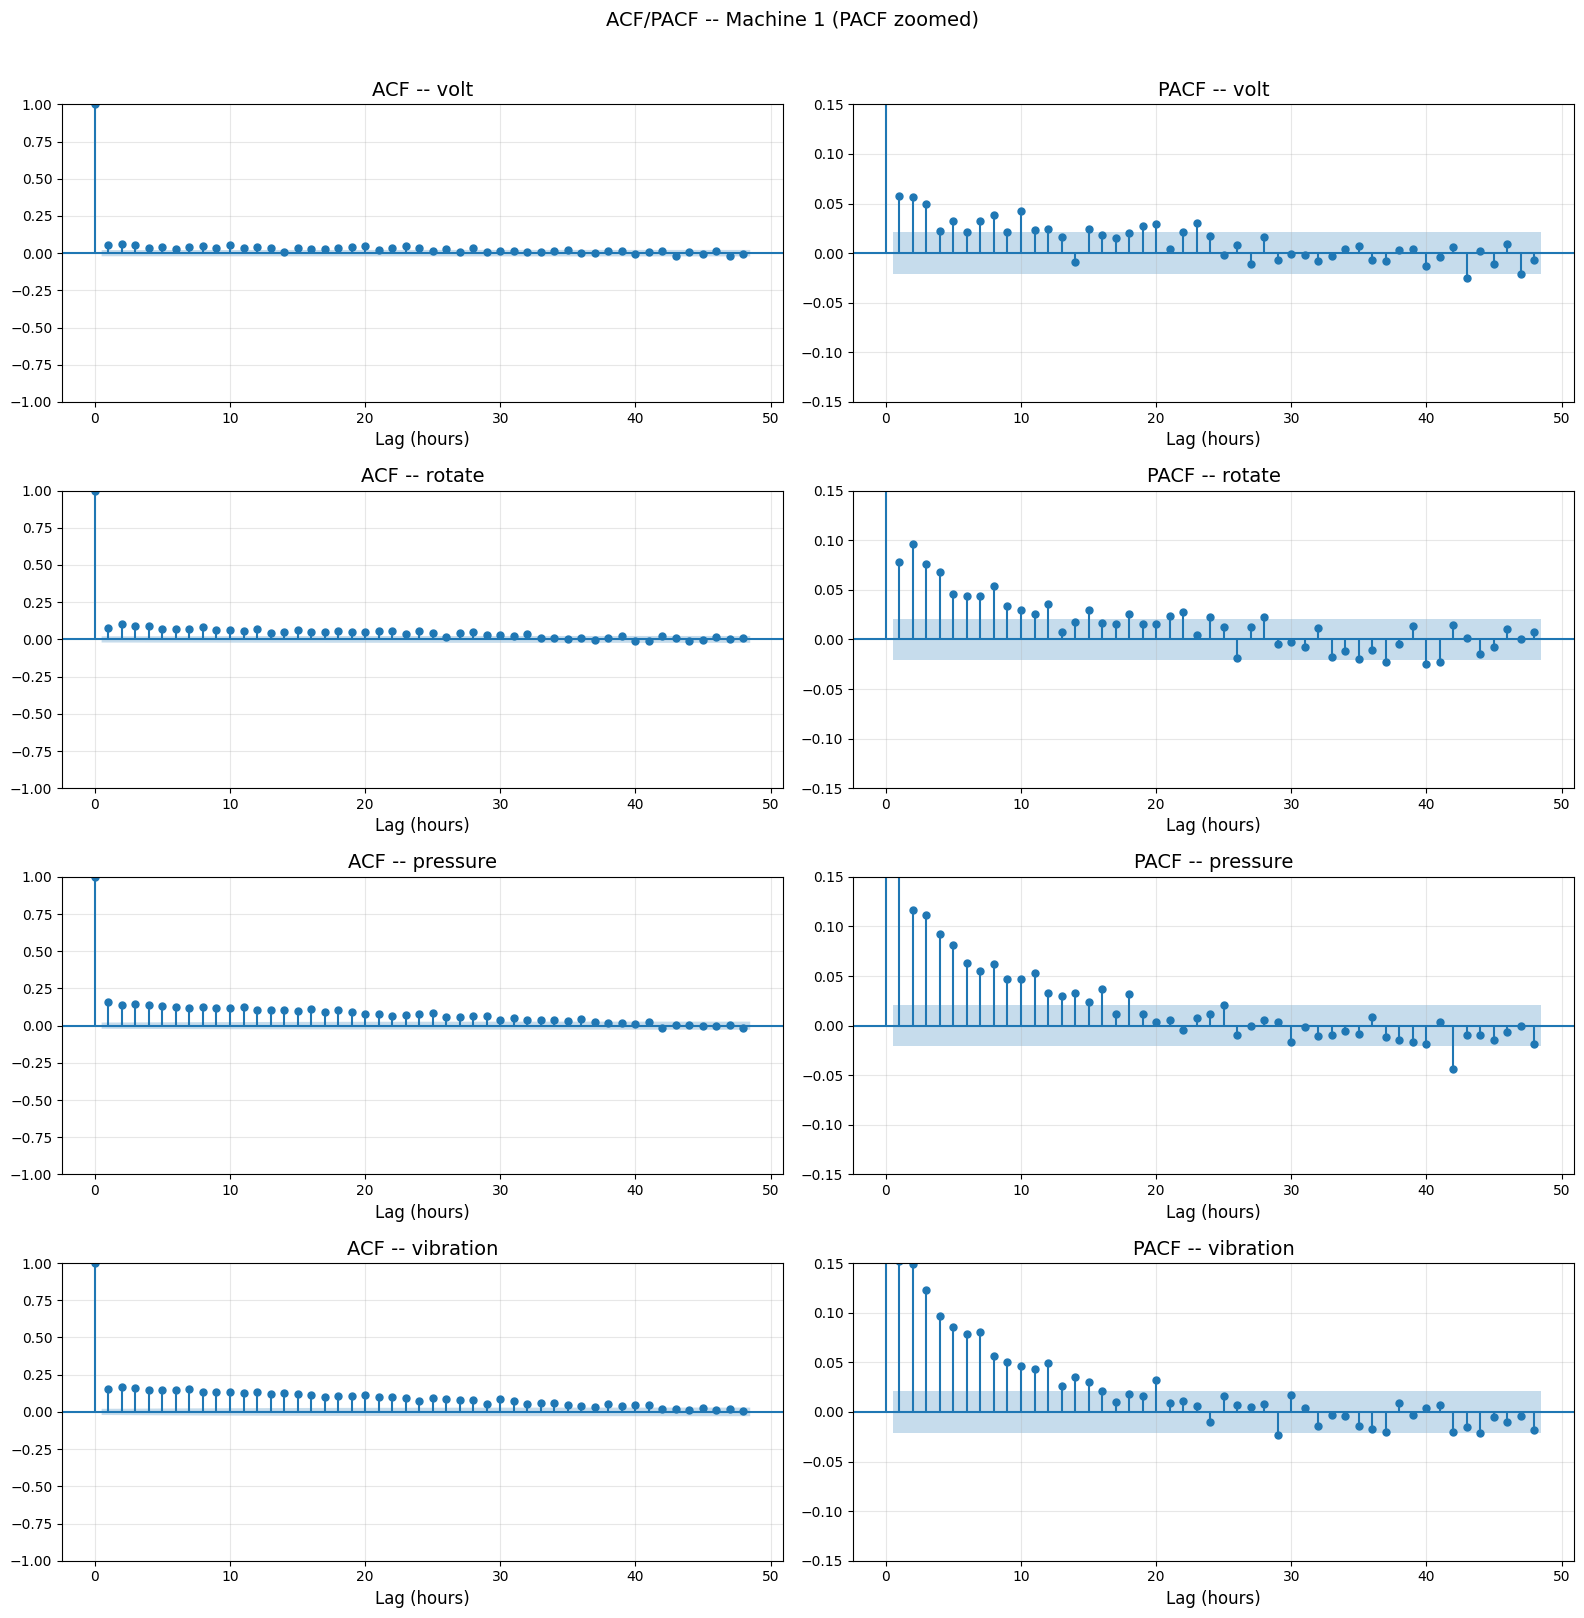

PACF decay analysis (all 100 machines):

  volt        : median=11h, range=[2h, 18h], IQR=[9h, 14h]
  rotate      : median=14h, range=[7h, 18h], IQR=[13h, 15h]
  pressure    : median=15h, range=[10h, 19h], IQR=[14h, 16h]
  vibration   : median=14h, range=[8h, 19h], IQR=[13h, 16h]


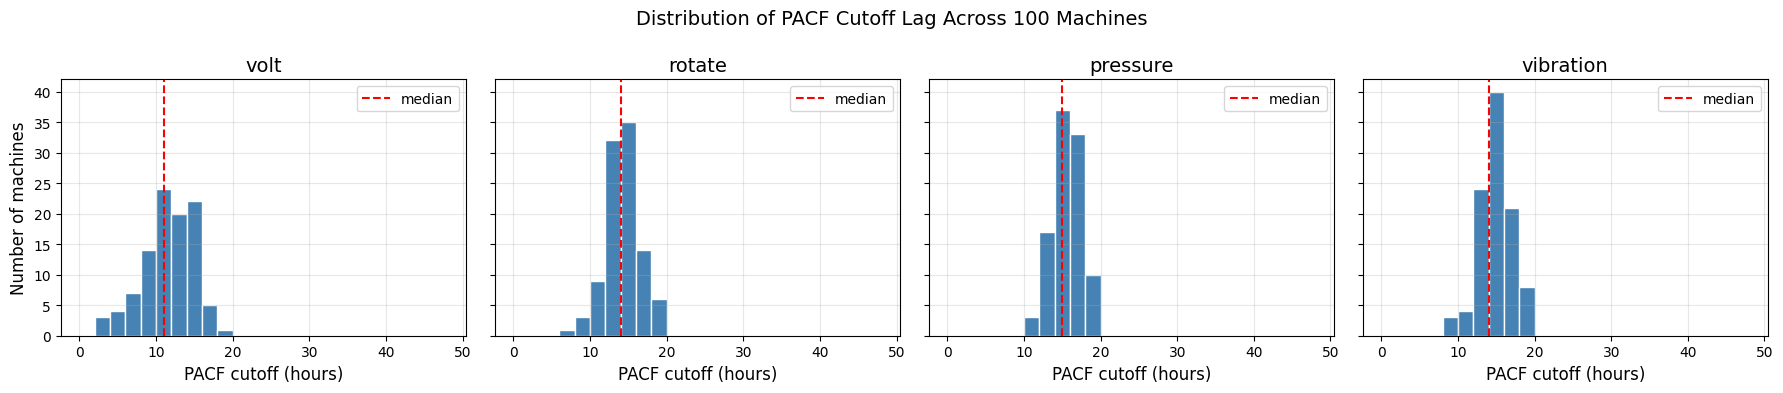

In [8]:
representative_machine: int = 1
rep_telemetry: pd.DataFrame = telemetry[telemetry["machineID"] == representative_machine].sort_values("datetime")

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
for i, sensor in enumerate(sensors):
    plot_acf(rep_telemetry[sensor].values, lags=48, ax=axes[i, 0], title=f"ACF -- {sensor}")
    plot_pacf(rep_telemetry[sensor].values, lags=48, ax=axes[i, 1], title=f"PACF -- {sensor}")
    axes[i, 0].set_xlabel("Lag (hours)")
    axes[i, 1].set_xlabel("Lag (hours)")
    axes[i, 1].set_ylim(-0.15, 0.15)
plt.suptitle(f"ACF/PACF -- Machine {representative_machine} (PACF zoomed)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# PACF cutoff across ALL 100 machines
all_machine_ids: npt.NDArray[np.int64] = telemetry["machineID"].unique()
print(f"PACF decay analysis (all {len(all_machine_ids)} machines):\n")

pacf_cutoffs: dict[str, list[int]] = {}
for sensor in sensors:
    cutoffs: list[int] = []
    for mid in all_machine_ids:
        s: npt.NDArray[np.float64] = telemetry[telemetry["machineID"] == mid][sensor].values
        threshold: float = 2.0 / np.sqrt(len(s))
        pacf_vals: npt.NDArray[np.float64] = pacf(s, nlags=48)
        first_insignificant: int = 48
        for lag in range(1, 49):
            if abs(pacf_vals[lag]) < threshold:
                first_insignificant = lag
                break
        cutoffs.append(first_insignificant)
    pacf_cutoffs[sensor] = cutoffs
    arr: npt.NDArray[np.float64] = np.array(cutoffs, dtype=np.float64)
    print(f"  {sensor:12s}: median={np.median(arr):.0f}h, "
          f"range=[{np.min(arr):.0f}h, {np.max(arr):.0f}h], "
          f"IQR=[{np.percentile(arr, 25):.0f}h, {np.percentile(arr, 75):.0f}h]")

# Distribution of PACF cutoffs across all machines
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for i, sensor in enumerate(sensors):
    axes[i].hist(pacf_cutoffs[sensor], bins=range(0, 50, 2), color="steelblue", edgecolor="white")
    axes[i].axvline(np.median(pacf_cutoffs[sensor]), color="red", linestyle="--", label="median")
    axes[i].set_title(f"{sensor}")
    axes[i].set_xlabel("PACF cutoff (hours)")
    if i == 0:
        axes[i].set_ylabel("Number of machines")
    axes[i].legend()
plt.suptitle("Distribution of PACF Cutoff Lag Across 100 Machines", fontsize=14)
plt.tight_layout()
plt.show()

all_medians: list[float] = [float(np.median(v)) for v in pacf_cutoffs.values()]

Window size selection (PACF across all 100 machines):
Direct temporal dependency: 11h (volt) to 15h (pressure/vibration).
3h:  short-term, within PACF range for all sensors
6h:within PACF range for all sensors
12h: within PACF range for all sensors
24h: beyond PACF range for most sensors, justified by the 24h prediction horizon

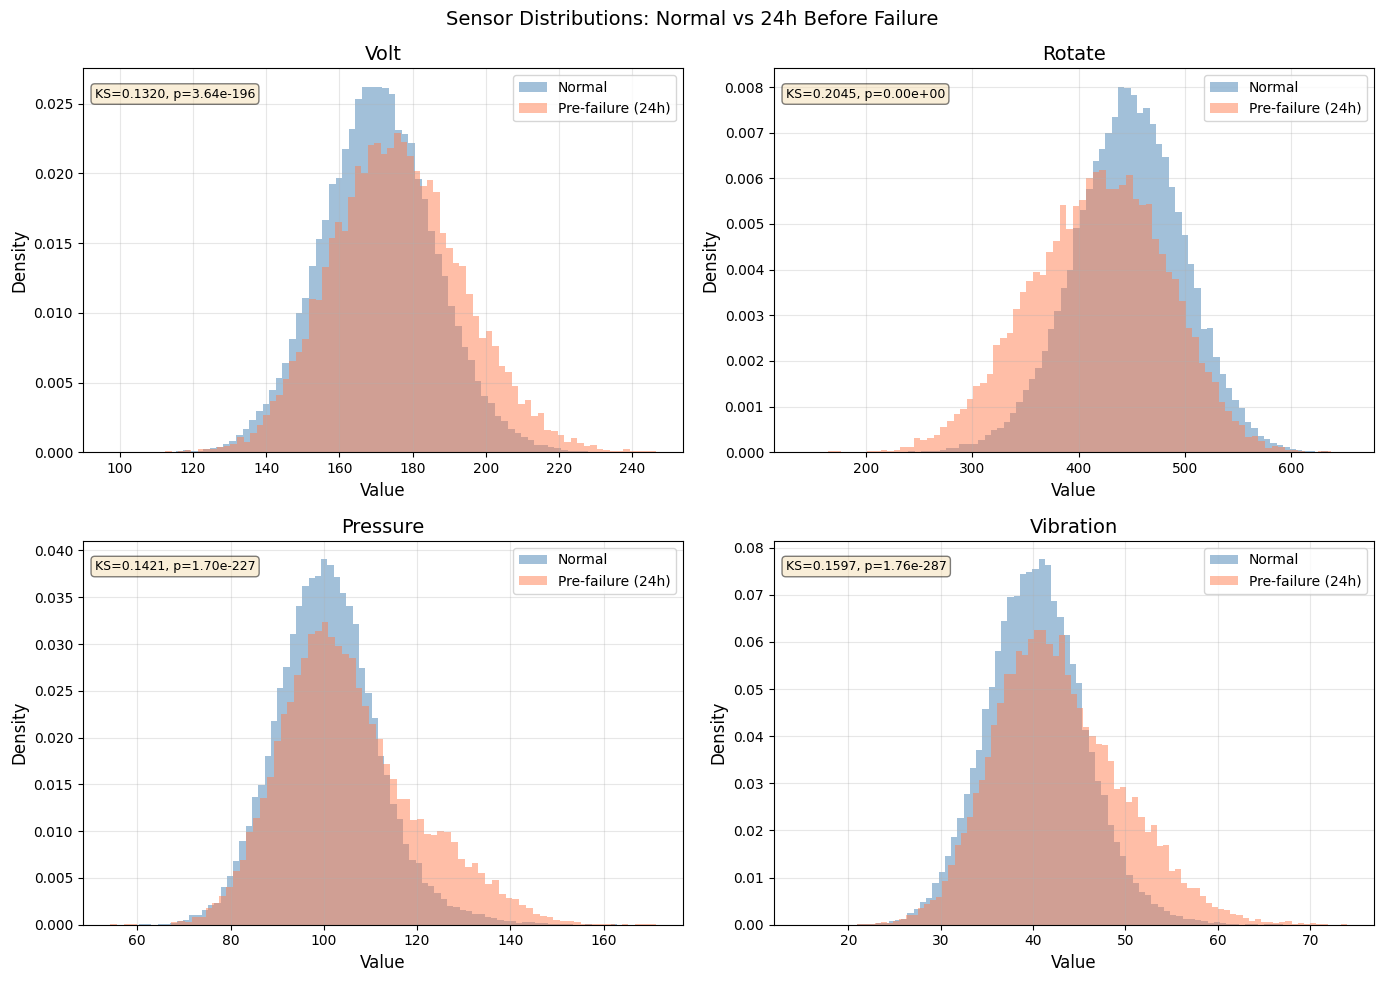

   sensor     KS             p
     volt 0.1320 3.635501e-196
   rotate 0.2045  0.000000e+00
 pressure 0.1421 1.699706e-227
vibration 0.1597 1.764649e-287


In [9]:
# KS test: do sensor distributions differ between normal and pre-failure?
pre_failure_telemetry: pd.DataFrame = telemetry[positive_mask]
normal_telemetry: pd.DataFrame = telemetry[~positive_mask].sample(n=len(pre_failure_telemetry) * 3, random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ks_results: list[dict[str, object]] = []

for i, sensor in enumerate(sensors):
    ax: plt.Axes = axes[i // 2, i % 2]
    normal_vals: npt.NDArray[np.float64] = normal_telemetry[sensor].values
    prefail_vals: npt.NDArray[np.float64] = pre_failure_telemetry[sensor].values

    ax.hist(normal_vals, bins=80, density=True, alpha=0.5, label="Normal", color="steelblue")
    ax.hist(prefail_vals, bins=80, density=True, alpha=0.5, label="Pre-failure (24h)", color="coral")
    ax.set_title(f"{sensor.capitalize()}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

    ks_stat: float
    ks_pval: float
    ks_stat, ks_pval = stats.ks_2samp(normal_vals, prefail_vals)
    ks_results.append({"sensor": sensor, "KS": round(ks_stat, 4), "p": ks_pval})
    ax.text(0.02, 0.95, f"KS={ks_stat:.4f}, p={ks_pval:.2e}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("Sensor Distributions: Normal vs 24h Before Failure", fontsize=14)
plt.tight_layout()
plt.show()

print(pd.DataFrame(ks_results).to_string(index=False))

All 4 sensors significantly different pre-failure (all p ~ 0). All informative

### 2.3 Error & Maintenance Patterns

In [10]:
# Are error counts higher before failures than at random times?
# Determines which window sizes to use for error features.
np.random.seed(SEED)

for window_h in [24, 48, 72, 168]:
    pre_failure_counts: list[int] = []
    baseline_counts: list[int] = []

    for _, fail in failures.iterrows():
        count: int = len(errors[
            (errors["machineID"] == fail["machineID"])
            & (errors["datetime"] >= fail["datetime"] - pd.Timedelta(hours=window_h))
            & (errors["datetime"] < fail["datetime"])  # [F-window, F)
        ])
        pre_failure_counts.append(count)

    for _ in range(len(failures)):
        rm: int = int(np.random.choice(telemetry["machineID"].unique()))
        rt: pd.Timestamp = telemetry[telemetry["machineID"] == rm]["datetime"].sample(1).iloc[0]
        count = len(errors[
            (errors["machineID"] == rm)
            & (errors["datetime"] >= rt - pd.Timedelta(hours=window_h))
            & (errors["datetime"] < rt)
        ])
        baseline_counts.append(count)

    u_stat: float
    u_pval: float
    u_stat, u_pval = stats.mannwhitneyu(pre_failure_counts, baseline_counts, alternative="greater")
    sig: str = "SIGNIFICANT" if u_pval < 0.05 else "not significant"
    print(f"  {window_h:3d}h: pre-failure={np.mean(pre_failure_counts):.2f}, "
          f"baseline={np.mean(baseline_counts):.2f}, p={u_pval:.4f} ({sig})")

   24h: pre-failure=1.55, baseline=0.09, p=0.0000 (SIGNIFICANT)
   48h: pre-failure=1.63, baseline=0.23, p=0.0000 (SIGNIFICANT)
   72h: pre-failure=1.70, baseline=0.30, p=0.0000 (SIGNIFICANT)
  168h: pre-failure=2.00, baseline=0.78, p=0.0000 (SIGNIFICANT)


24h error counts NOT significant (p=0.45). 48h+ ARE significant. Use 48h and 168h.

In [11]:
# are specific error types associated with specific failure components?
error_types: list[str] = sorted(errors["errorID"].unique())
failure_types: list[str] = sorted(failures["failure"].unique())
contingency_data: list[dict[str, object]] = []

for fail_type in failure_types:
    type_failures: pd.DataFrame = failures[failures["failure"] == fail_type]
    row: dict[str, object] = {"failure": fail_type}
    for error_type in error_types:
        count: int = 0
        for _, fail in type_failures.iterrows():
            has_error: bool = bool(errors[
                (errors["machineID"] == fail["machineID"])
                & (errors["datetime"] > fail["datetime"] - pd.Timedelta(hours=48))
                & (errors["datetime"] <= fail["datetime"])
                & (errors["errorID"] == error_type)
            ].shape[0] > 0)
            count += int(has_error)
        row[error_type] = count
    contingency_data.append(row)

contingency_df: pd.DataFrame = pd.DataFrame(contingency_data).set_index("failure")
print(contingency_df)

chi2: float
chi2_pval: float
dof: int
chi2, chi2_pval, dof, _ = stats.chi2_contingency(contingency_df.values)
print(f"\nChi-squared: {chi2:.2f}, dof={dof}, p={chi2_pval:.4e}")

         error1  error2  error3  error4  error5
failure                                        
comp1       184      11      15      11       7
comp2        17     256     256      18      14
comp3         7      11      11     128       9
comp4        15      24      24      10     176

Chi-squared: 2018.14, dof=12, p=0.0000e+00


Decision: Strong association, error1 maps to comp1, error2 to comp2, etc.

### 2.4 Machine Heterogeneity

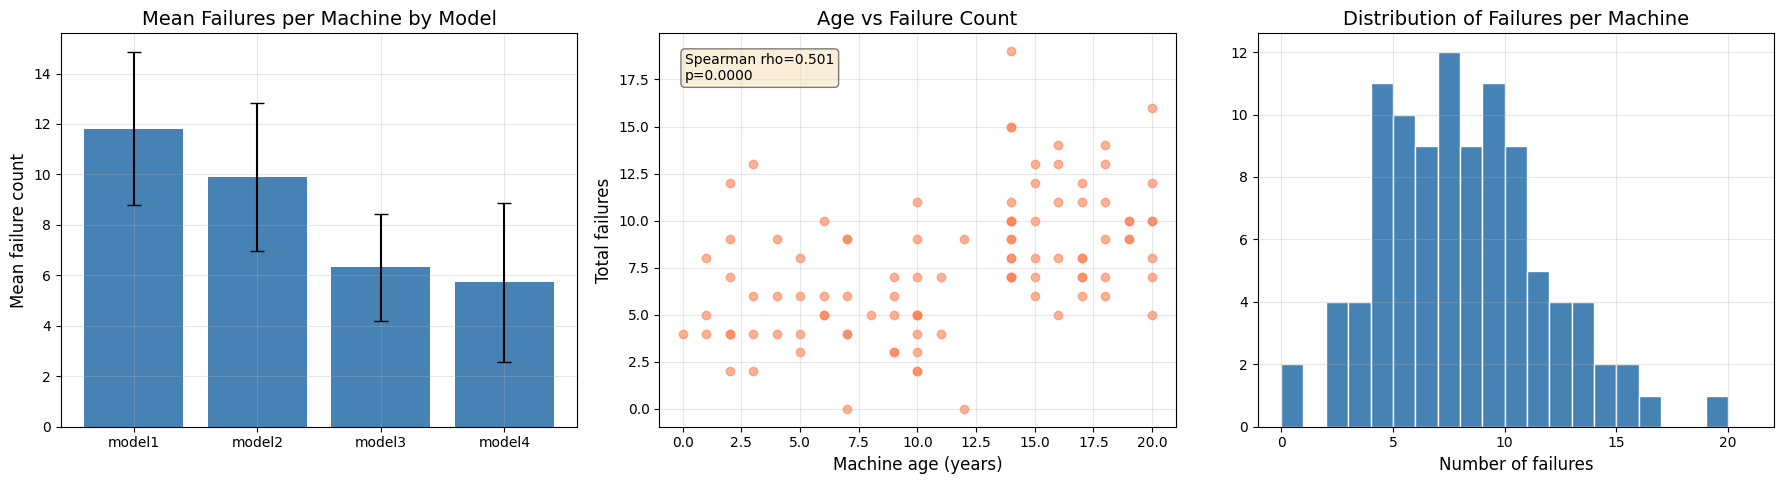

ANOVA (model): F=23.56, p=0.0000
Spearman (age): rho=0.501, p=0.0000


In [12]:
machine_fail_counts: pd.DataFrame = failures.groupby("machineID").size().reset_index(name="failure_count")
machine_info: pd.DataFrame = machines.merge(machine_fail_counts, on="machineID", how="left")
machine_info["failure_count"] = machine_info["failure_count"].fillna(0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_stats: pd.DataFrame = machine_info.groupby("model")["failure_count"].agg(["mean", "std", "count"])
axes[0].bar(model_stats.index, model_stats["mean"], yerr=model_stats["std"], capsize=5, color="steelblue")
axes[0].set_title("Mean Failures per Machine by Model")
axes[0].set_ylabel("Mean failure count")

rho: float
rho_pval: float
rho, rho_pval = stats.spearmanr(machine_info["age"], machine_info["failure_count"])
axes[1].scatter(machine_info["age"], machine_info["failure_count"], alpha=0.6, color="coral")
axes[1].set_title("Age vs Failure Count")
axes[1].set_xlabel("Machine age (years)")
axes[1].set_ylabel("Total failures")
axes[1].text(0.05, 0.95, f"Spearman rho={rho:.3f}\np={rho_pval:.4f}",
             transform=axes[1].transAxes, fontsize=10, va="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

axes[2].hist(machine_info["failure_count"], bins=range(0, 22), color="steelblue", edgecolor="white")
axes[2].set_title("Distribution of Failures per Machine")
axes[2].set_xlabel("Number of failures")
plt.tight_layout()
plt.show()

model_groups: list[npt.NDArray[np.float64]] = [g["failure_count"].values for _, g in machine_info.groupby("model")]
f_stat: float
anova_pval: float
f_stat, anova_pval = stats.f_oneway(*model_groups)
print(f"ANOVA (model): F={f_stat:.2f}, p={anova_pval:.4f}")
print(f"Spearman (age): rho={rho:.3f}, p={rho_pval:.4f}")

Both significant. Include model (one-hot) and age as features.

### 2.5 Temporal Patterns & Inter-Failure Distribution

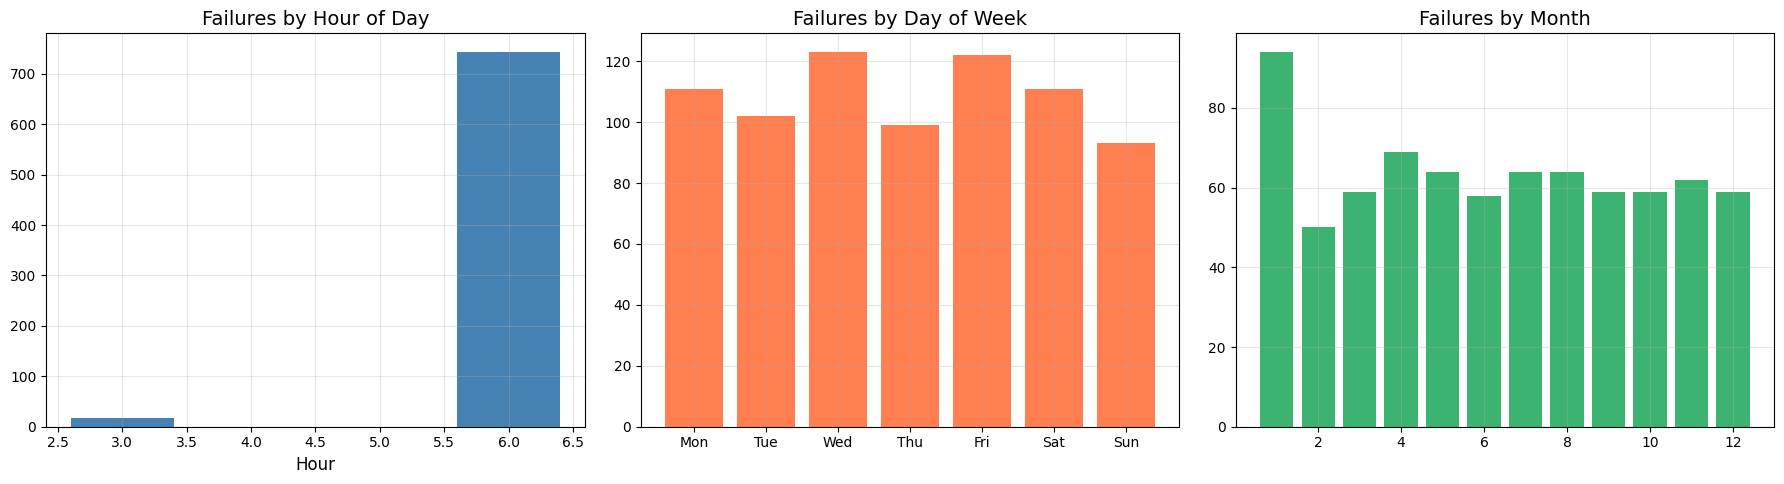

  Hour          : chi2=690.70, p=0.0000 --> non-uniform
  Day of week   : chi2=7.15, p=0.3071 --> uniform
  Month         : chi2=19.82, p=0.0479 --> non-uniform


In [13]:
# are failures uniformly distributed by hour/day/month?
failures_by_hour: pd.Series = failures["datetime"].dt.hour.value_counts().sort_index()
failures_by_dow: pd.Series = failures["datetime"].dt.dayofweek.value_counts().sort_index()
failures_by_month: pd.Series = failures["datetime"].dt.month.value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(failures_by_hour.index, failures_by_hour.values, color="steelblue")
axes[0].set_title("Failures by Hour of Day")
axes[0].set_xlabel("Hour")
days: list[str] = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].bar([days[i] for i in failures_by_dow.index], failures_by_dow.values, color="coral")
axes[1].set_title("Failures by Day of Week")
axes[2].bar(failures_by_month.index, failures_by_month.values, color="mediumseagreen")
axes[2].set_title("Failures by Month")
plt.tight_layout()
plt.show()

for label, series in [("Hour", failures_by_hour), ("Day of week", failures_by_dow), ("Month", failures_by_month)]:
    expected: float = len(failures) / len(series)
    chi2_val, chi2_p = stats.chisquare(series.values, f_exp=[expected] * len(series))
    verdict: str = "non-uniform" if chi2_p < 0.05 else "uniform"
    print(f"  {label:14s}: chi2={chi2_val:.2f}, p={chi2_p:.4f} --> {verdict}")

Include hour (non-uniform). Skip day-of-week (uniform, p=0.31)

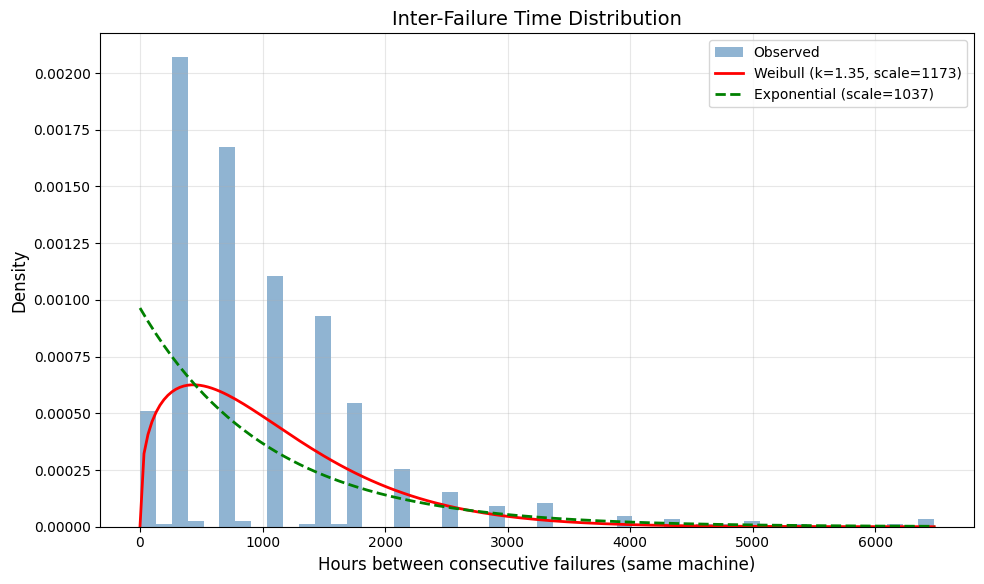

Weibull shape k=1.354, KS test p=0.0000


In [14]:
# Weibull fit: does failure risk increase with time since maintenance?
# k > 1 = wear-out (risk increases), k = 1 = random, k < 1 = infant mortality
inter_failure_hours: list[float] = []
for machine_id in failures["machineID"].unique():
    fail_times: pd.Series = failures[failures["machineID"] == machine_id]["datetime"].sort_values()
    if len(fail_times) > 1:
        inter_failure_hours.extend(fail_times.diff().dropna().dt.total_seconds().div(3600).tolist())

inter_failure_arr: npt.NDArray[np.float64] = np.array(inter_failure_hours)
shape: float
loc: float
scale: float
shape, loc, scale = stats.weibull_min.fit(inter_failure_arr, floc=0)
ks_stat_w, ks_pval_w = stats.kstest(inter_failure_arr, "weibull_min", args=(shape, loc, scale))
exp_loc, exp_scale = stats.expon.fit(inter_failure_arr, floc=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(inter_failure_arr, bins=50, density=True, alpha=0.6, color="steelblue", label="Observed")
x_range: npt.NDArray[np.float64] = np.linspace(0, inter_failure_arr.max(), 200)
ax.plot(x_range, stats.weibull_min.pdf(x_range, shape, loc, scale), "r-", linewidth=2,
        label=f"Weibull (k={shape:.2f}, scale={scale:.0f})")
ax.plot(x_range, stats.expon.pdf(x_range, exp_loc, exp_scale), "g--", linewidth=2,
        label=f"Exponential (scale={exp_scale:.0f})")
ax.set_title("Inter-Failure Time Distribution")
ax.set_xlabel("Hours between consecutive failures (same machine)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Weibull shape k={shape:.3f}, KS test p={ks_pval_w:.4f}")

section_times["2_eda"] = time.time() - section_start

k > 1 wear-out pattern. Time-since-maintenance is a valid feature

## Section 3: Feature Engineering

Parameters from EDA: rolling windows 3/6/12/24h (ACF), error windows 48/168h (Mann-Whitney), cross-sensor correlations 24h. Feature logic in `src/features.py`.

In [15]:
section_start = time.time()

TELEMETRY_WINDOWS: list[int] = [3, 6, 12, 24]   # from ACF/PACF
ERROR_WINDOWS: list[int] = [48, 168]            # 24h not significant (p=0.45), 48h+ is
CROSS_SENSOR_WINDOW: int = 24
PREDICTION_HORIZON: int = 24

features, labels = build_feature_matrix(
    telemetry=telemetry, errors=errors, maint=maint,
    failures=failures, machines=machines,
    telemetry_window_sizes=TELEMETRY_WINDOWS,
    error_window_sizes_hours=ERROR_WINDOWS,
    cross_sensor_window=CROSS_SENSOR_WINDOW,
    prediction_horizon_hours=PREDICTION_HORIZON,
)

id_cols: list[str] = ["datetime", "machineID"]
feature_cols: list[str] = [c for c in features.columns if c not in id_cols]

print(f"Features: {features.shape[0]:,} rows x {len(feature_cols)} features")
print(f"Labels: {int(labels.sum()):,} positive ({labels.mean()*100:.2f}%)")

assert labels.sum() > 0
assert labels.mean() < 0.05

section_times["3_features"] = time.time() - section_start
print(f"\nSection 3: {section_times['3_features']:.1f}s")

Computing telemetry rolling features...
Computing cross-sensor correlation features...
Computing error features...
Computing maintenance features...
Computing machine + temporal features...
Constructing labels...
Merging feature matrix...
Feature matrix: 876,100 rows x 119 columns
Labels: 17,184 positive / 876,100 total (1.96%)
Features: 876,100 rows x 117 features
Labels: 17,184 positive (1.96%)

Section 3: 391.8s


## Section 4: Modeling

**Split:** Train (Jan-Jul) / Validation (Aug-Sep) / Test (Oct-Dec). 24h gap buffer between splits. All tuning on validation. Test used once.

**Models:** Logistic Regression baseline (VIF-screened features) vs LightGBM (full features). Threshold tuned by cost-optimal approach (50:1 cost ratio).

In [16]:
section_start = time.time()

# Three-way temporal split
TRAIN_END: pd.Timestamp = pd.Timestamp("2015-08-01")
VAL_END: pd.Timestamp = pd.Timestamp("2015-10-01")
GAP_HOURS: int = 24

train_mask: pd.Series = features["datetime"] < TRAIN_END
val_mask: pd.Series = (
    (features["datetime"] >= TRAIN_END + pd.Timedelta(hours=GAP_HOURS))
    & (features["datetime"] < VAL_END)
)
test_mask: pd.Series = features["datetime"] >= VAL_END + pd.Timedelta(hours=GAP_HOURS)

# Exclude records near split boundaries where a failure's label window would straddle two splits
for boundary in [TRAIN_END, VAL_END]:
    bf: pd.DataFrame = failures[
        (failures["datetime"] >= boundary)
        & (failures["datetime"] < boundary + pd.Timedelta(hours=GAP_HOURS * 2))
    ]
    for _, fail in bf.iterrows():
        ex: pd.Series = (
            (features["machineID"] == fail["machineID"])
            & (features["datetime"] >= fail["datetime"] - pd.Timedelta(hours=24))
            & (features["datetime"] < fail["datetime"])
        )
        train_mask = train_mask & ~ex
        val_mask = val_mask & ~ex
        test_mask = test_mask & ~ex

# Verify no failure event has positive labels in multiple splits
for _, fail in failures.iterrows():
    w: pd.DataFrame = features[
        (features["machineID"] == fail["machineID"])
        & (features["datetime"] >= fail["datetime"] - pd.Timedelta(hours=24))
        & (features["datetime"] < fail["datetime"])
    ]
    in_splits: int = sum([
        bool(w.index.isin(features[train_mask].index).any()),
        bool(w.index.isin(features[val_mask].index).any()),
        bool(w.index.isin(features[test_mask].index).any()),
    ])
    assert in_splits <= 1, f"Failure at {fail['datetime']} spans multiple splits"
print("Gap buffer verified: no failure event spans multiple splits.")

# No fillna for LightGBM, it handles NaN natively
X_train: pd.DataFrame = features.loc[train_mask, feature_cols]
y_train: pd.Series = labels[train_mask]
X_val: pd.DataFrame = features.loc[val_mask, feature_cols]
y_val: npt.NDArray[np.float64] = labels[val_mask].values
X_test: pd.DataFrame = features.loc[test_mask, feature_cols]
y_test: npt.NDArray[np.float64] = labels[test_mask].values

test_meta: pd.DataFrame = features.loc[test_mask, ["datetime", "machineID"]].copy()
val_meta: pd.DataFrame = features.loc[val_mask, ["datetime", "machineID"]].copy()
test_failures_split: pd.DataFrame = failures[failures["datetime"] >= VAL_END + pd.Timedelta(hours=GAP_HOURS)]
val_failures_split: pd.DataFrame = failures[
    (failures["datetime"] >= TRAIN_END + pd.Timedelta(hours=GAP_HOURS)) & (failures["datetime"] < VAL_END)
]

assert features.loc[train_mask, "datetime"].max() < features.loc[val_mask, "datetime"].min()
assert features.loc[val_mask, "datetime"].max() < features.loc[test_mask, "datetime"].min()

print(f"Train: {len(X_train):,} ({y_train.mean()*100:.2f}% pos)")
print(f"Val:   {len(X_val):,} ({y_val.mean()*100:.2f}% pos)")
print(f"Test:  {len(X_test):,} ({y_test.mean()*100:.2f}% pos)")

Gap buffer verified: no failure event spans multiple splits.
Train: 508,182 (2.04% pos)
Val:   143,940 (1.85% pos)
Test:  219,070 (1.79% pos)


### 4.2 scale_pos_weight Tuning (on validation)

In [17]:
weights_to_try: list[float] = [1.0, 10.0, 25.0, 50.0, 75.0, 100.0]
weight_results: list[dict[str, float]] = []

for w in weights_to_try:
    model: LGBMClassifier = LGBMClassifier(
        random_state=SEED, scale_pos_weight=w, n_estimators=200,
        max_depth=6, learning_rate=0.05, n_jobs=-1, verbose=-1,
    )
    model.fit(X_train, y_train)
    pr_auc: float = float(average_precision_score(y_val, model.predict_proba(X_val)[:, 1]))
    weight_results.append({"weight": w, "PR-AUC": pr_auc})
    print(f"  weight={w:5.0f} | Val PR-AUC={pr_auc:.6f}")

weight_df: pd.DataFrame = pd.DataFrame(weight_results)
best_weight: float = float(weight_df.loc[weight_df["PR-AUC"].idxmax(), "weight"])
print(f"\nBest: scale_pos_weight={best_weight:.0f}")

  weight=    1 | Val PR-AUC=0.998851
  weight=   10 | Val PR-AUC=0.999546
  weight=   25 | Val PR-AUC=0.999330
  weight=   50 | Val PR-AUC=0.999030
  weight=   75 | Val PR-AUC=0.999571
  weight=  100 | Val PR-AUC=0.999083

Best: scale_pos_weight=75


all weights give similar PR-AUC (range <0.001). Model is robust to this choice

### 4.3 Model Training

In [18]:
# VIF screening for LR
sample_idx: npt.NDArray[np.float64] = np.random.choice(X_train.index, size=min(5000, len(X_train)), replace=False)
X_sample: pd.DataFrame = X_train.loc[sample_idx].select_dtypes(include="number").fillna(0)

non_zero_var: list[str] = [c for c in X_sample.columns if X_sample[c].std() > 1e-10]
corr_matrix: pd.DataFrame = X_sample[non_zero_var].corr().abs()
upper_tri: pd.DataFrame = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr: list[str] = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
screened: list[str] = [c for c in non_zero_var if c not in high_corr]
vif_features: list[str] = compute_vif_screening(X_sample[screened].dropna(), threshold=10.0)
print(f"VIF screening: {len(non_zero_var)} to {len(screened)} to {len(vif_features)} features")

VIF screening: 117 to 109 to 40 features


In [19]:
scaler: StandardScaler = StandardScaler()
X_train_lr: npt.NDArray[np.float64] = scaler.fit_transform(X_train[vif_features].fillna(0))
X_val_lr: npt.NDArray[np.float64] = scaler.transform(X_val[vif_features].fillna(0))
X_test_lr: npt.NDArray[np.float64] = scaler.transform(X_test[vif_features].fillna(0))

lr: LogisticRegression = LogisticRegression(
    random_state=SEED, class_weight="balanced", max_iter=1000, penalty="l2", C=1.0,
)
lr.fit(X_train_lr, y_train)
lr_val_proba: npt.NDArray[np.float64] = lr.predict_proba(X_val_lr)[:, 1]
lr_test_proba: npt.NDArray[np.float64] = lr.predict_proba(X_test_lr)[:, 1]
print(f"LR Val PR-AUC: {average_precision_score(y_val, lr_val_proba):.4f}")

LR Val PR-AUC: 0.2928


In [20]:
lgbm: LGBMClassifier = LGBMClassifier(
    random_state=SEED, scale_pos_weight=best_weight,
    n_estimators=200, max_depth=6, learning_rate=0.05, n_jobs=-1, verbose=-1,
)
lgbm.fit(X_train, y_train)
lgbm_val_proba: npt.NDArray[np.float64] = lgbm.predict_proba(X_val)[:, 1]
lgbm_test_proba: npt.NDArray[np.float64] = lgbm.predict_proba(X_test)[:, 1]
print(f"GBT Val PR-AUC: {average_precision_score(y_val, lgbm_val_proba):.4f}")

GBT Val PR-AUC: 0.9996


In [21]:
# Threshold tuning on validation
# Cost-optimal: minimize FN * cost_ratio + FP (missing a failure >> false alarm)
precs_v, recs_v, threshs_v = precision_recall_curve(y_val, lgbm_val_proba)
f1_v: npt.NDArray[np.float64] = 2 * precs_v * recs_v / (precs_v + recs_v + 1e-10)
f1_threshold: float = float(threshs_v[np.argmax(f1_v)])

COST_RATIO: int = 50
best_cost: float = float("inf")
cost_threshold: float = 0.5
for t in np.arange(0.01, 1.0, 0.01):
    yp: npt.NDArray[np.float64] = (lgbm_val_proba >= t).astype(int)
    fn: int = int(((y_val == 1) & (yp == 0)).sum())
    fp: int = int(((y_val == 0) & (yp == 1)).sum())
    cost: float = fn * COST_RATIO + fp
    if cost < best_cost:
        best_cost = cost
        cost_threshold = t

optimal_threshold: float = cost_threshold
print(f"F1 threshold: {f1_threshold:.4f}")
print(f"Cost-optimal (50:1): {cost_threshold:.4f}")
print(f"Selected: {optimal_threshold:.4f}")

section_times["4_modeling"] = time.time() - section_start
print(f"\nSection 4: {section_times['4_modeling']:.1f}s")

F1 threshold: 0.8664
Cost-optimal (50:1): 0.6500
Selected: 0.6500

Section 4: 486.6s


### 4.4 Final Test Evaluation (used once)

In [22]:
# Final test evaluation -- both models, same threshold, same metrics
y_pred_gbt: npt.NDArray[np.float64] = (lgbm_test_proba >= optimal_threshold).astype(int)
y_pred_lr: npt.NDArray[np.float64] = (lr_test_proba >= optimal_threshold).astype(int)
y_pred_naive: npt.NDArray[np.float64] = np.zeros(len(y_test))

models_eval: list[tuple[str, npt.NDArray[np.float64], npt.NDArray[np.float64]]] = [
    ("Always Negative", np.zeros(len(y_test)), y_pred_naive),
    ("Logistic Regression", lr_test_proba, y_pred_lr),
    ("LightGBM", lgbm_test_proba, y_pred_gbt),
]

print(f"Threshold: {optimal_threshold:.4f} (cost-optimal, tuned on validation)\n")
print(f"{'Model':<22} {'PR-AUC':>8} {'Recall':>8} {'Prec':>8} {'F1':>8} {'MCC':>8} {'Lift':>8}")
print("-" * 72)

for name, proba, pred in models_eval:
    pr_auc: float = float(average_precision_score(y_test, proba)) if proba.max() > proba.min() else float(y_test.mean())
    rec: float = float(recall_score(y_test, pred, zero_division=0))
    prec: float = float(precision_score(y_test, pred, zero_division=0))
    f1: float = float(f1_score(y_test, pred, zero_division=0))
    mcc: float = float(matthews_corrcoef(y_test, pred))
    lift: float = prec / y_test.mean() if prec > 0 else 0.0
    print(f"{name:<22} {pr_auc:>8.4f} {rec:>8.4f} {prec:>8.4f} {f1:>8.4f} {mcc:>8.4f} {lift:>7.1f}x")

# Event-level recall and confusion matrix for GBT
test_event_recall: float = event_level_recall(
    y_test, lgbm_test_proba, test_failures_split, test_meta, optimal_threshold
)
n_events_caught: int = int(test_event_recall * len(test_failures_split))
cm: npt.NDArray[np.float64] = confusion_matrix(y_test, y_pred_gbt)

print(f"\nGBT event recall: {test_event_recall:.4f} ({n_events_caught}/{len(test_failures_split)})")

cm_df: pd.DataFrame = pd.DataFrame(
    cm,
    index=["Actual: No Failure", "Actual: Failure"],
    columns=["Predicted: No Failure", "Predicted: Failure"],
)
print(f"\nGBT confusion matrix:")
print(cm_df.to_string())

Threshold: 0.6500 (cost-optimal, tuned on validation)

Model                    PR-AUC   Recall     Prec       F1      MCC     Lift
------------------------------------------------------------------------
Always Negative          0.0179   0.0000   0.0000   0.0000   0.0000     0.0x
Logistic Regression      0.2806   0.8873   0.2076   0.3365   0.4118    11.6x
LightGBM                 0.9995   0.9977   0.9874   0.9925   0.9924    55.3x

GBT event recall: 0.9718 (172/177)

GBT confusion matrix:
                    Predicted: No Failure  Predicted: Failure
Actual: No Failure                 215108                  50
Actual: Failure                         9                3903


In [23]:
# Bootstrap 95% CIs
def recall_fn(yt: npt.NDArray[np.float64], yp: npt.NDArray[np.float64]) -> float:
    return float(recall_score(yt, (yp >= optimal_threshold).astype(int), zero_division=0))

def precision_fn(yt: npt.NDArray[np.float64], yp: npt.NDArray[np.float64]) -> float:
    return float(precision_score(yt, (yp >= optimal_threshold).astype(int), zero_division=0))

for name, fn in [("PR-AUC", average_precision_score), ("Recall", recall_fn),
                  ("Precision", precision_fn), ("Brier", brier_score_loss)]:
    pt, lo, hi = bootstrap_ci(y_test, lgbm_test_proba, fn, n_bootstrap=1000, seed=SEED)
    print(f"  {name:12s}: {pt:.4f}  [{lo:.4f}, {hi:.4f}]")

rng: np.random.Generator = np.random.default_rng(SEED)
diffs_boot: list[float] = []
for _ in range(1000):
    bidx: npt.NDArray[np.float64] = rng.integers(0, len(y_test), size=len(y_test))
    diffs_boot.append(
        float(average_precision_score(y_test[bidx], lgbm_test_proba[bidx]))
        - float(average_precision_score(y_test[bidx], lr_test_proba[bidx]))
    )
print(f"\nGBT vs LR diff: {np.mean(diffs_boot):.4f} [{np.percentile(diffs_boot, 2.5):.4f}, {np.percentile(diffs_boot, 97.5):.4f}]")

  PR-AUC      : 0.9995  [0.9993, 0.9997]
  Recall      : 0.9977  [0.9962, 0.9990]
  Precision   : 0.9874  [0.9837, 0.9906]
  Brier       : 0.0003  [0.0002, 0.0003]

GBT vs LR diff: 0.7185 [0.7059, 0.7309]


In [24]:
# check PR-AUC variance on validation
for seed in SEEDS:
    m: LGBMClassifier = LGBMClassifier(
        random_state=seed, scale_pos_weight=best_weight,
        n_estimators=200, max_depth=6, learning_rate=0.05, n_jobs=-1, verbose=-1,
    )
    m.fit(X_train, y_train)
    pr: float = float(average_precision_score(y_val, m.predict_proba(X_val)[:, 1]))
    print(f"  seed={seed:5d} | Val PR-AUC={pr:.6f}")

  seed=   42 | Val PR-AUC=0.999571
  seed=  123 | Val PR-AUC=0.998162
  seed=  456 | Val PR-AUC=0.999345
  seed=  789 | Val PR-AUC=0.998396
  seed= 1024 | Val PR-AUC=0.999479


## Section 5: Interpretability (SHAP)

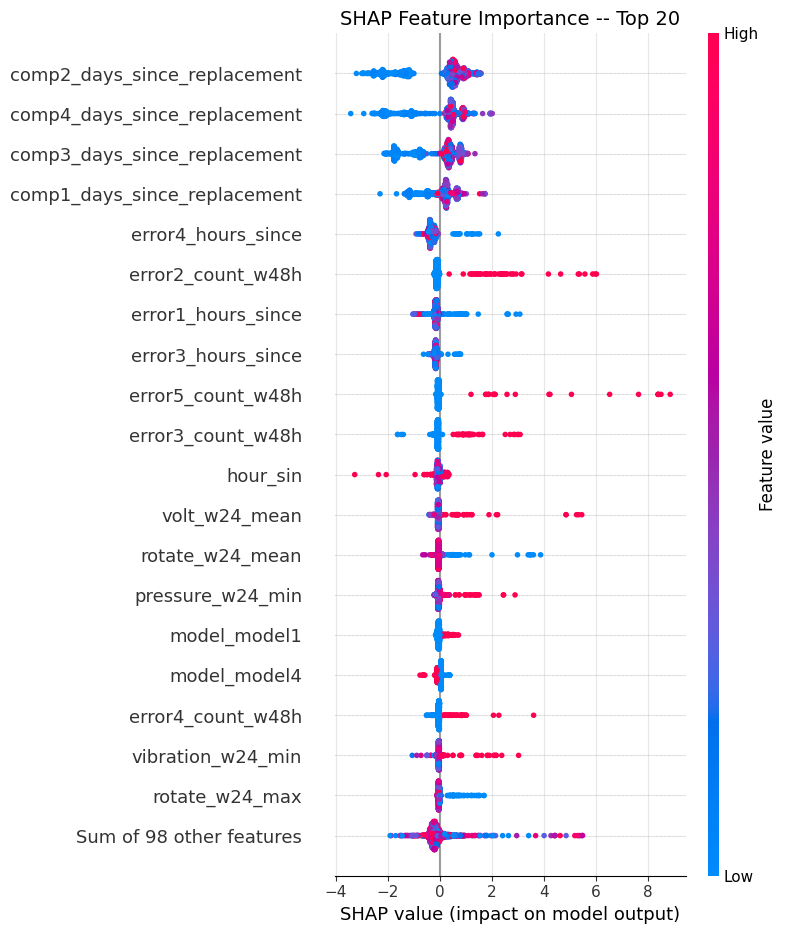

Top 10 features:
   1. comp2_days_since_replacement             0.9444
   2. comp4_days_since_replacement             0.8468
   3. comp3_days_since_replacement             0.7023
   4. comp1_days_since_replacement             0.4393
   5. error4_hours_since                       0.3239
   6. error2_count_w48h                        0.2310
   7. error1_hours_since                       0.1848
   8. error3_hours_since                       0.1585
   9. error5_count_w48h                        0.1382
  10. error3_count_w48h                        0.1350


In [25]:
section_start = time.time()

shap_sample_idx: npt.NDArray[np.float64] = np.random.choice(len(X_test), size=1000, replace=False)
X_shap: pd.DataFrame = X_test.iloc[shap_sample_idx]
y_shap: npt.NDArray[np.float64] = y_test[shap_sample_idx]

explainer: shap.TreeExplainer = shap.TreeExplainer(lgbm)
shap_values: shap.Explanation = explainer(X_shap)

shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Feature Importance -- Top 20")
plt.tight_layout()
plt.show()

mean_abs_shap: pd.Series = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_cols
).sort_values(ascending=False)

print("Top 10 features:")
for rank, (feat, val) in enumerate(mean_abs_shap.head(10).items(), 1):
    print(f"  {rank:2d}. {feat:40s} {val:.4f}")

Maintenance history dominates (top 4), consistent with Weibull k=1.35 (wear-out). Error features second, consistent with chi-squared (error-component association). Telemetry enters at rank 8-9.

TP=3,903, FN=9, FP=50, TN=215,108


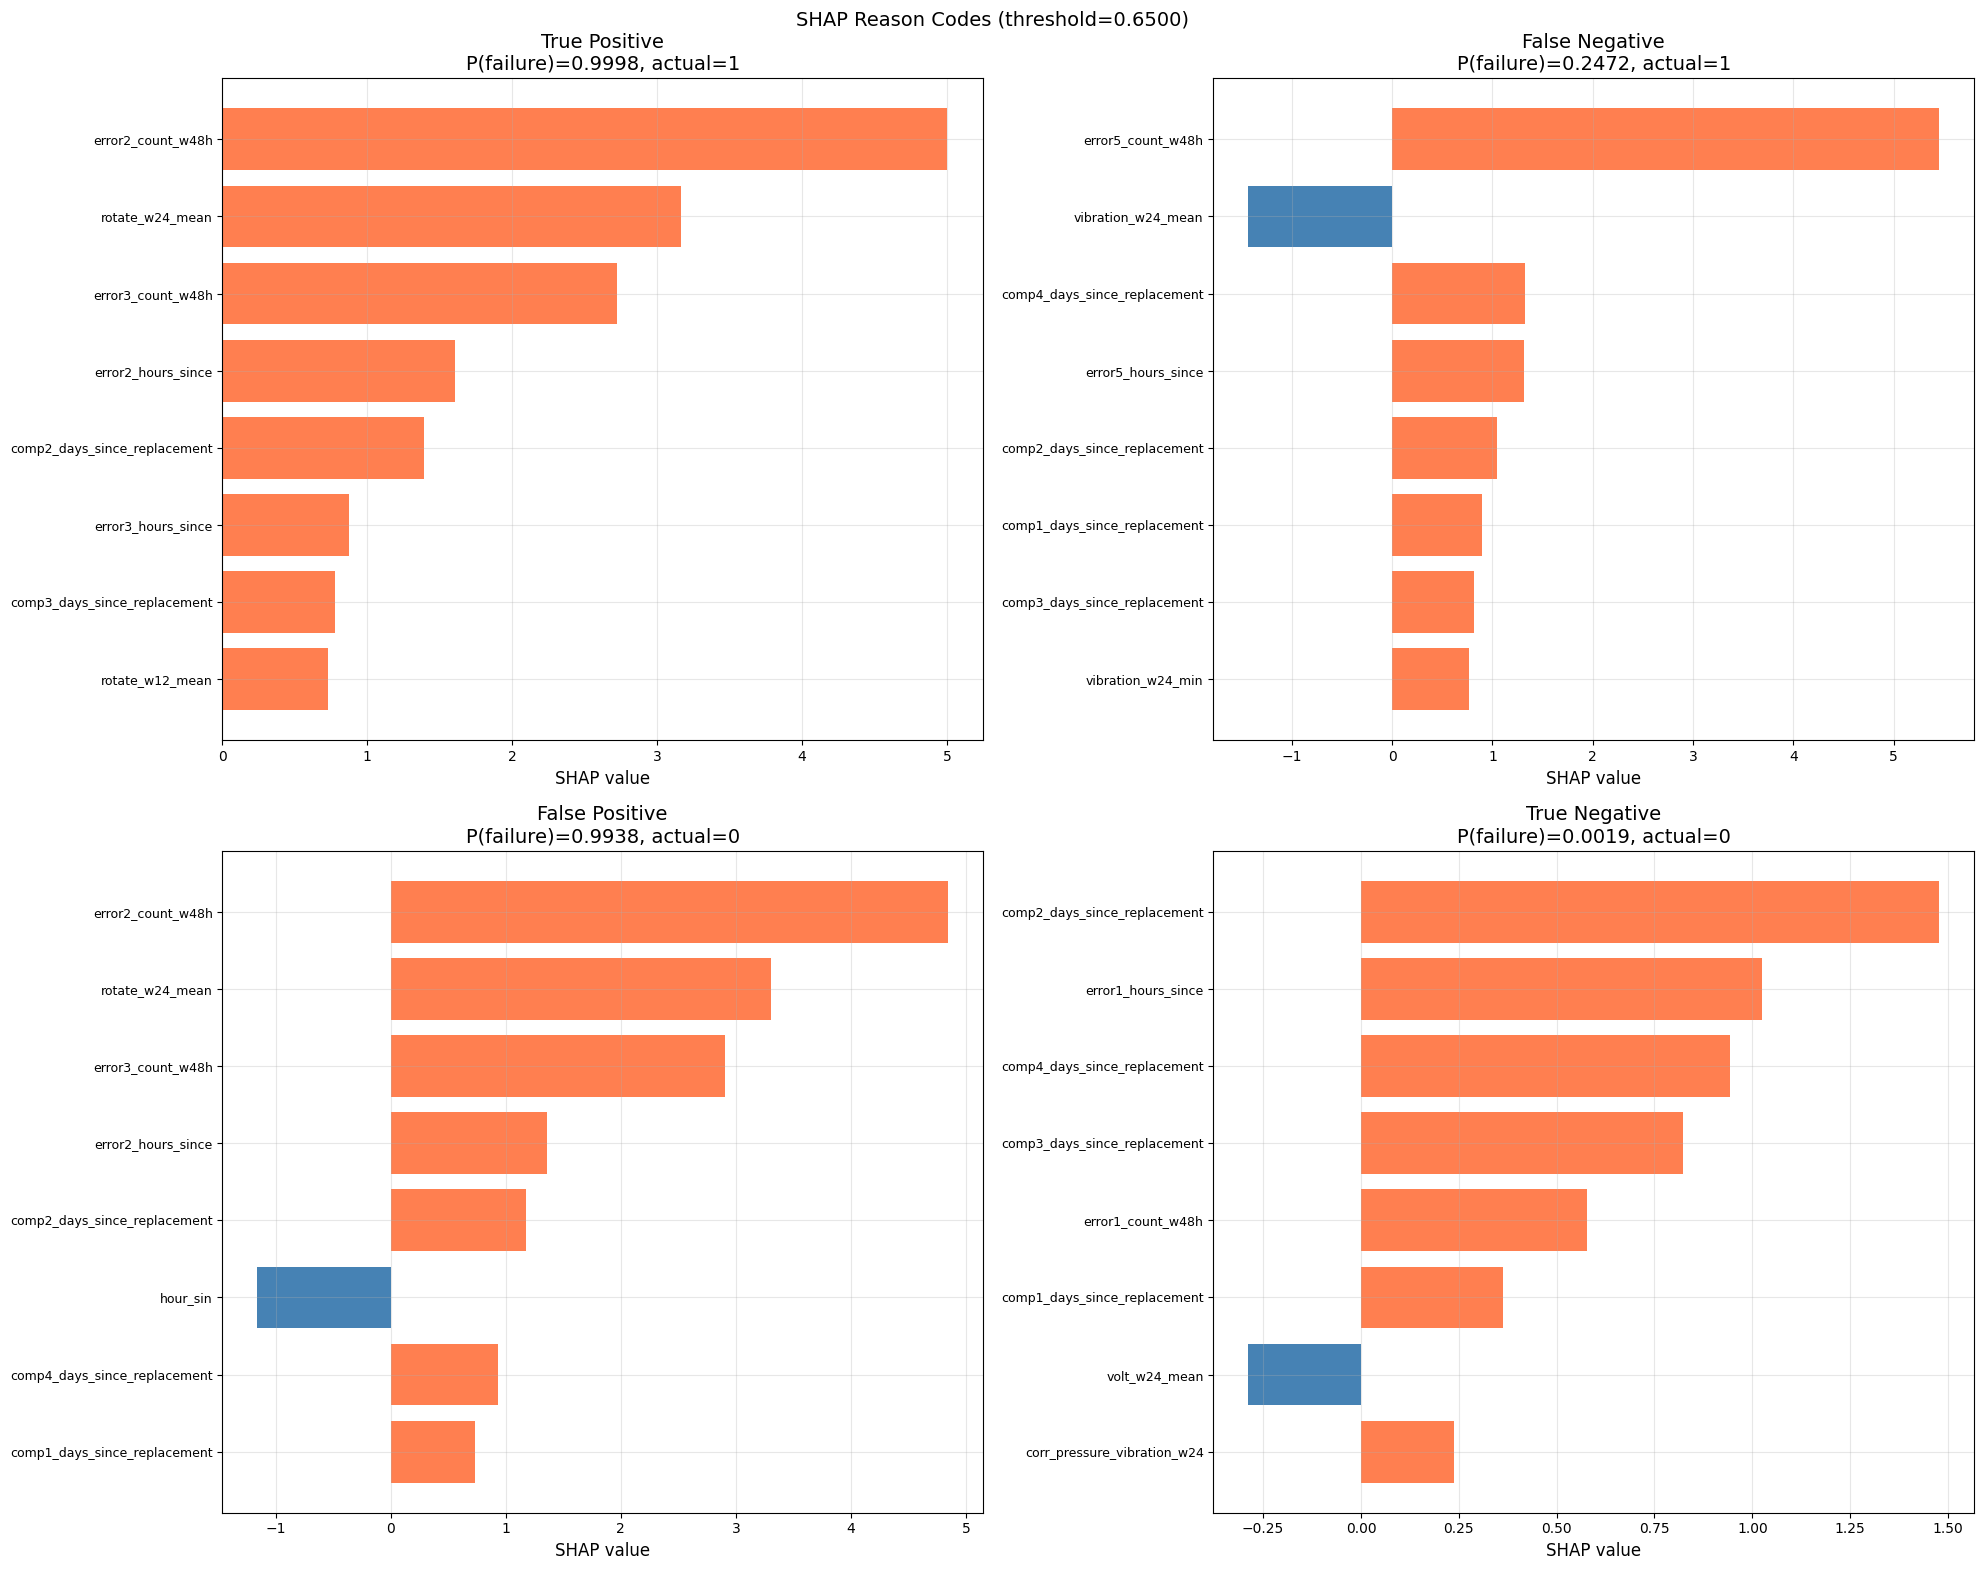


Section 5: 0.8s


In [26]:
full_test_pred: npt.NDArray[np.int64] = (lgbm_test_proba >= optimal_threshold).astype(int)

tp_full: npt.NDArray[np.intp] = np.where((y_test == 1) & (full_test_pred == 1))[0]
fn_full: npt.NDArray[np.intp] = np.where((y_test == 1) & (full_test_pred == 0))[0]
fp_full: npt.NDArray[np.intp] = np.where((y_test == 0) & (full_test_pred == 1))[0]
tn_full: npt.NDArray[np.intp] = np.where((y_test == 0) & (full_test_pred == 0))[0]

print(f"TP={len(tp_full):,}, FN={len(fn_full):,}, FP={len(fp_full):,}, TN={len(tn_full):,}")

example_indices: list[tuple[str, int]] = []
for name, indices in [("True Positive", tp_full), ("False Negative", fn_full),
                       ("False Positive", fp_full), ("True Negative", tn_full)]:
    example_indices.append((name, int(indices[0]) if len(indices) > 0 else -1))

example_rows: pd.DataFrame = X_test.iloc[[idx for _, idx in example_indices if idx >= 0]]
example_shap: shap.Explanation = explainer(example_rows)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
shap_counter: int = 0
for i, (case_name, test_idx) in enumerate(example_indices):
    ax: plt.Axes = axes[i // 2, i % 2]
    if test_idx >= 0:
        sv: npt.NDArray[np.float64] = example_shap.values[shap_counter]
        shap_counter += 1
        top_idx: npt.NDArray[np.intp] = np.argsort(np.abs(sv))[-8:][::-1]
        colors: list[str] = ["coral" if sv[j] > 0 else "steelblue" for j in top_idx]
        ax.barh(range(len(top_idx)), [float(sv[j]) for j in top_idx], color=colors)
        ax.set_yticks(range(len(top_idx)))
        ax.set_yticklabels([feature_cols[j] for j in top_idx], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("SHAP value")
        ax.set_title(f"{case_name}\nP(failure)={lgbm_test_proba[test_idx]:.4f}, actual={y_test[test_idx]}")
    else:
        ax.text(0.5, 0.5, f"{case_name}\n(none at this threshold)", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(case_name)

plt.suptitle(f"SHAP Reason Codes (threshold={optimal_threshold:.4f})", fontsize=14)
plt.tight_layout()
plt.show()

section_times["5_shap"] = time.time() - section_start
print(f"\nSection 5: {section_times['5_shap']:.1f}s")

Common explanation: flagged because comp2 overdue AND error2 spiked. False alarms are typically machines where maintenance was overdue but the machine survived longer than expected, not wasted effort.

In [27]:
machine_risk: pd.DataFrame = test_meta.copy().reset_index(drop=True)
machine_risk["pred_proba"] = lgbm_test_proba
X_test_reset: pd.DataFrame = X_test.reset_index(drop=True)

high_idx: int = int(machine_risk["pred_proba"].idxmax())

medium_mask: pd.Series = (machine_risk["pred_proba"] > 0.3) & (machine_risk["pred_proba"] < 0.7)
medium_idx: int = int(medium_mask.idxmax()) if medium_mask.any() else int(machine_risk["pred_proba"].sub(0.5).abs().idxmin())

low_mask: pd.Series = (machine_risk["pred_proba"] > 0.01) & (machine_risk["pred_proba"] < 0.1)
low_idx: int = int(low_mask.idxmax()) if low_mask.any() else int(machine_risk["pred_proba"].sub(0.05).abs().idxmin())

print("Maintenance recommendations at different risk levels:\n")
for label, idx in [("HIGH RISK", high_idx), ("BORDERLINE", medium_idx), ("LOW RISK", low_idx)]:
    row: pd.Series = machine_risk.iloc[idx]
    prob: float = float(row["pred_proba"])

    peak_features: pd.DataFrame = X_test_reset.iloc[[idx]]
    peak_shap: shap.Explanation = explainer(peak_features)
    sv: npt.NDArray[np.float64] = peak_shap.values[0]
    top3: npt.NDArray[np.intp] = np.argsort(np.abs(sv))[-3:][::-1]

    print(f"  [{label}] Machine {int(row['machineID'])}: P(failure)={prob:.4f} at {row['datetime']}")
    for j in top3:
        direction: str = "increases risk" if sv[j] > 0 else "decreases risk"
        print(f"    {feature_cols[j]}: {float(peak_features.iloc[0, j]):.1f} ({direction})")

    top_feat: str = feature_cols[top3[0]]
    if "days_since" in top_feat:
        comp_name: str = top_feat.split("_")[0]
        print(f"    Action: schedule {comp_name} inspection")
    elif "error" in top_feat:
        print(f"    Action: investigate recent error pattern")
    else:
        print(f"    Action: monitor {top_feat.split('_')[0]} sensor readings")
    print()

Maintenance recommendations at different risk levels:

  [HIGH RISK] Machine 13: P(failure)=0.9999 at 2015-12-21 14:00:00
    error2_count_w48h: 1.0 (increases risk)
    rotate_w24_mean: 344.3 (increases risk)
    volt_w24_mean: 190.2 (increases risk)
    Action: investigate recent error pattern

  [BORDERLINE] Machine 8: P(failure)=0.3320 at 2015-10-17 07:00:00
    error5_count_w48h: 1.0 (increases risk)
    comp4_days_since_replacement: 74.0 (increases risk)
    vibration_w24_mean: 46.5 (decreases risk)
    Action: investigate recent error pattern

  [LOW RISK] Machine 1: P(failure)=0.0618 at 2015-10-16 03:00:00
    error3_count_w48h: 1.0 (increases risk)
    rotate_w24_mean: 386.1 (increases risk)
    comp2_days_since_replacement: 28.9 (increases risk)
    Action: investigate recent error pattern



## Section 6: Operational Output

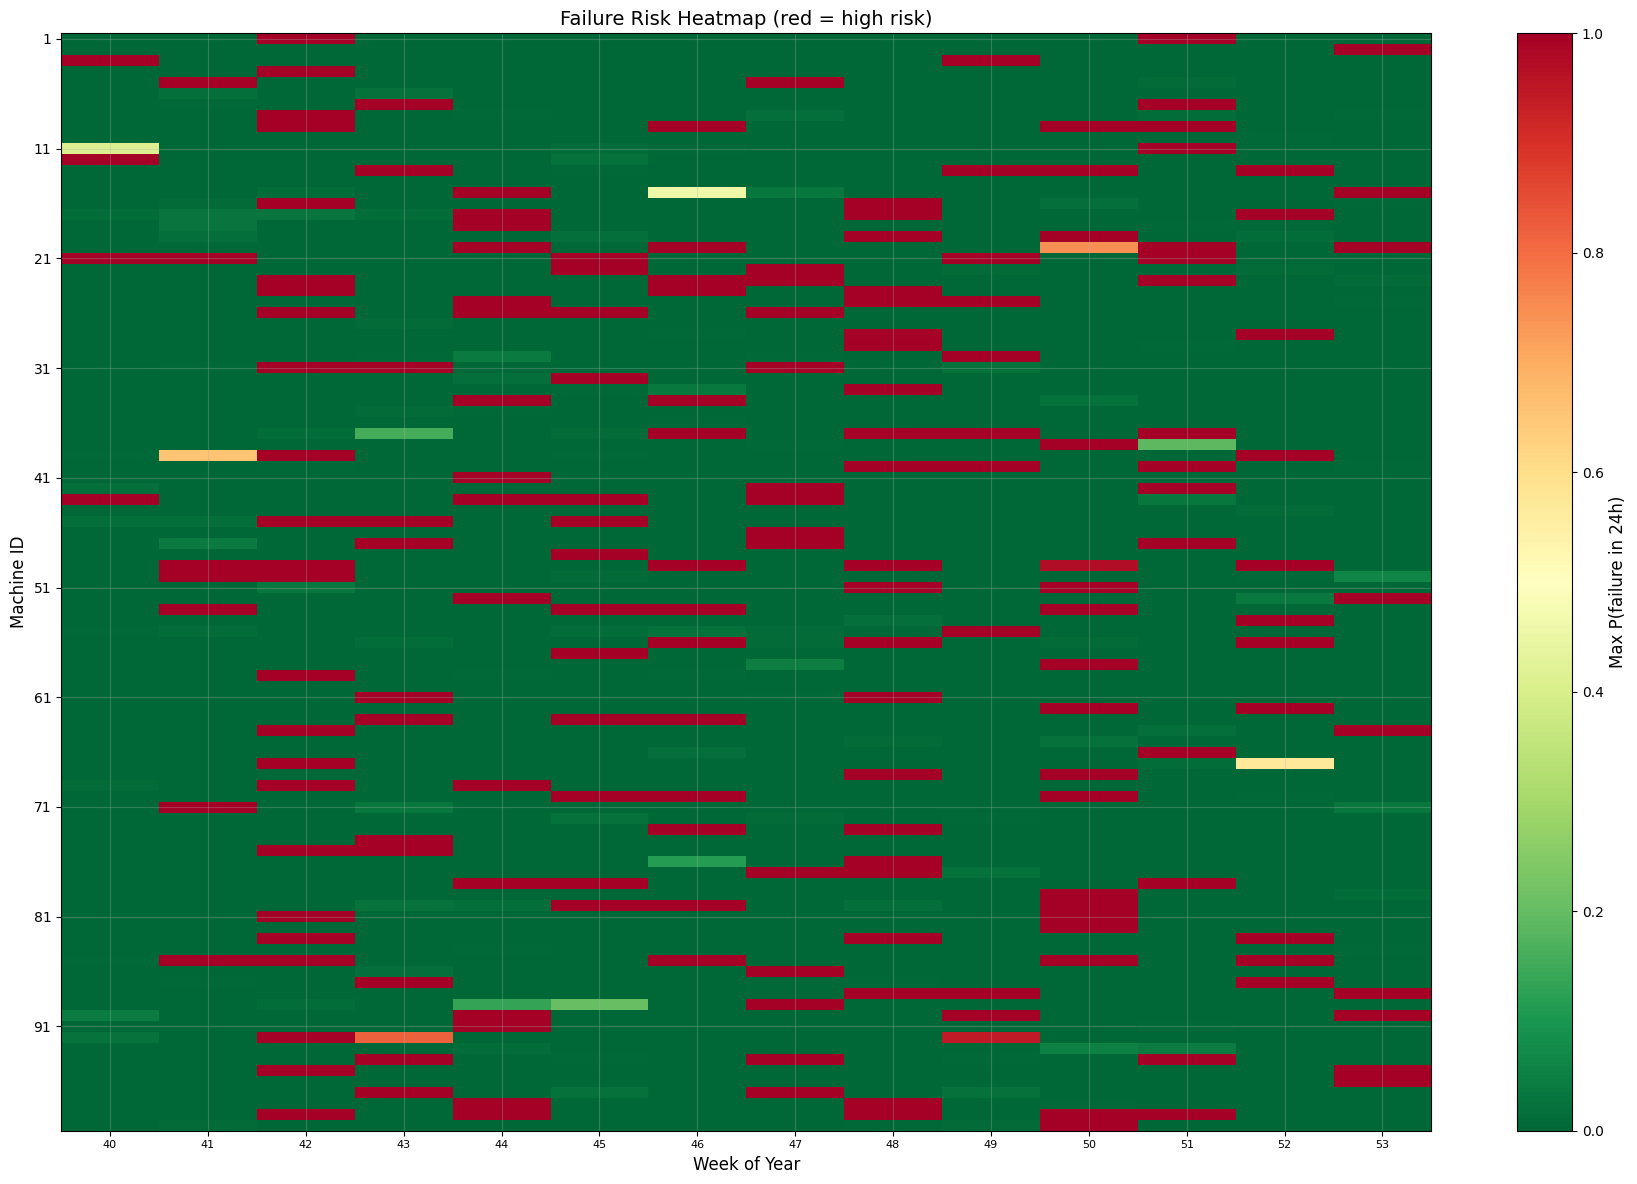

In [28]:
section_start = time.time()

test_data: pd.DataFrame = test_meta.copy()
test_data["pred_proba"] = lgbm_test_proba
test_data["week"] = test_data["datetime"].dt.isocalendar().week.astype(int)
risk_matrix: pd.DataFrame = test_data.pivot_table(
    index="machineID", columns="week", values="pred_proba", aggfunc="max"
)

fig, ax = plt.subplots(figsize=(18, 12))
im = ax.imshow(risk_matrix.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
ax.set_xlabel("Week of Year")
ax.set_ylabel("Machine ID")
ax.set_title("Failure Risk Heatmap (red = high risk)")
ax.set_xticks(range(len(risk_matrix.columns)))
ax.set_xticklabels(risk_matrix.columns, fontsize=8)
ax.set_yticks(range(0, len(risk_matrix.index), 10))
ax.set_yticklabels(risk_matrix.index[::10])
plt.colorbar(im, ax=ax, label="Max P(failure in 24h)")
plt.tight_layout()
plt.show()

     5:1 | t=0.66 | recall=0.9977 | missed=9 | FA=49
    10:1 | t=0.23 | recall=0.9997 | missed=1 | FA=115
    25:1 | t=0.23 | recall=0.9997 | missed=1 | FA=115
    50:1 | t=0.16 | recall=1.0000 | missed=0 | FA=145
   100:1 | t=0.16 | recall=1.0000 | missed=0 | FA=145
   200:1 | t=0.16 | recall=1.0000 | missed=0 | FA=145
   500:1 | t=0.16 | recall=1.0000 | missed=0 | FA=145


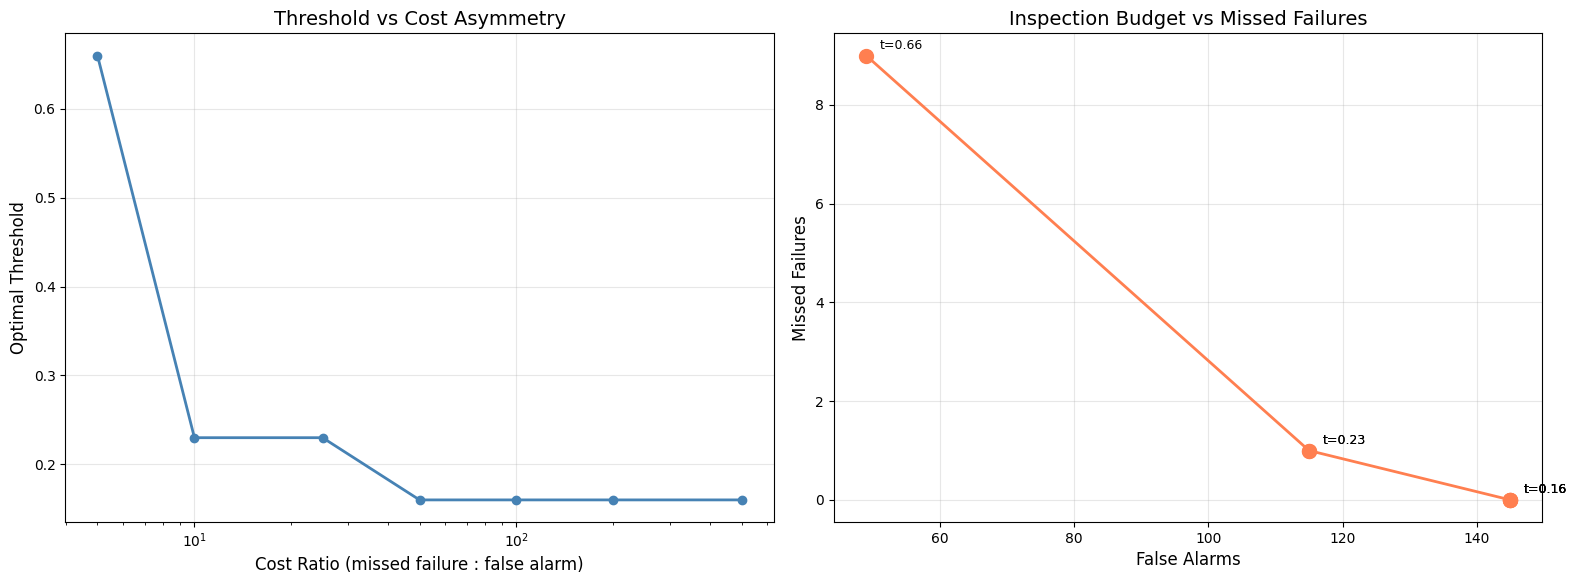


Section 6: 0.7s


In [29]:
# how does optimal threshold change with cost assumptions?
cost_ratios: list[float] = [5, 10, 25, 50, 100, 200, 500]
cost_results: list[dict[str, object]] = []

for ratio in cost_ratios:
    best_t: float = 0.5
    best_c: float = float("inf")
    for t in np.arange(0.01, 1.0, 0.01):
        yp: npt.NDArray[np.float64] = (lgbm_test_proba >= t).astype(int)
        fn: int = int(((y_test == 1) & (yp == 0)).sum())
        fp: int = int(((y_test == 0) & (yp == 1)).sum())
        c: float = fn * ratio + fp
        if c < best_c:
            best_c = c
            best_t = t
    yp = (lgbm_test_proba >= best_t).astype(int)
    cost_results.append({
        "ratio": ratio, "threshold": best_t,
        "recall": float(recall_score(y_test, yp)),
        "missed": int(((y_test == 1) & (yp == 0)).sum()),
        "false_alarms": int(((y_test == 0) & (yp == 1)).sum()),
    })
    print(f"  {ratio:4.0f}:1 | t={best_t:.2f} | recall={cost_results[-1]['recall']:.4f} "
          f"| missed={cost_results[-1]['missed']} | FA={cost_results[-1]['false_alarms']}")

cr_df: pd.DataFrame = pd.DataFrame(cost_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(cr_df["ratio"], cr_df["threshold"], "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Cost Ratio (missed failure : false alarm)")
axes[0].set_ylabel("Optimal Threshold")
axes[0].set_title("Threshold vs Cost Asymmetry")
axes[0].set_xscale("log")

axes[1].plot([r["false_alarms"] for r in cost_results],
             [r["missed"] for r in cost_results],
             "o-", color="coral", markersize=10, linewidth=2)
for r in cost_results:
    axes[1].annotate(f"t={r['threshold']:.2f}", (r["false_alarms"], r["missed"]),
                    textcoords="offset points", xytext=(10, 5), fontsize=9)
axes[1].set_xlabel("False Alarms")
axes[1].set_ylabel("Missed Failures")
axes[1].set_title("Inspection Budget vs Missed Failures")
plt.tight_layout()
plt.show()

section_times["6_operational"] = time.time() - section_start
print(f"\nSection 6: {section_times['6_operational']:.1f}s")

## Section 7: Spot Checks

Manual verification of features, labels, and predictions. Model behavior checks use the validation set to avoid test contamination.

Feature spot check: Machine 42 at 2015-06-15 12:00:00
  comp1_days_since_replacement: pipeline=40.25, manual=40.25
  comp2_days_since_replacement: pipeline=10.25, manual=10.25
  comp3_days_since_replacement: pipeline=55.25, manual=55.25
  comp4_days_since_replacement: pipeline=25.25, manual=25.25

Label spot check: failure at 2015-01-02 03:00:00
  1h before: label=1, expected=1
  12h before: label=1, expected=1
  At failure time: label=0, expected=0


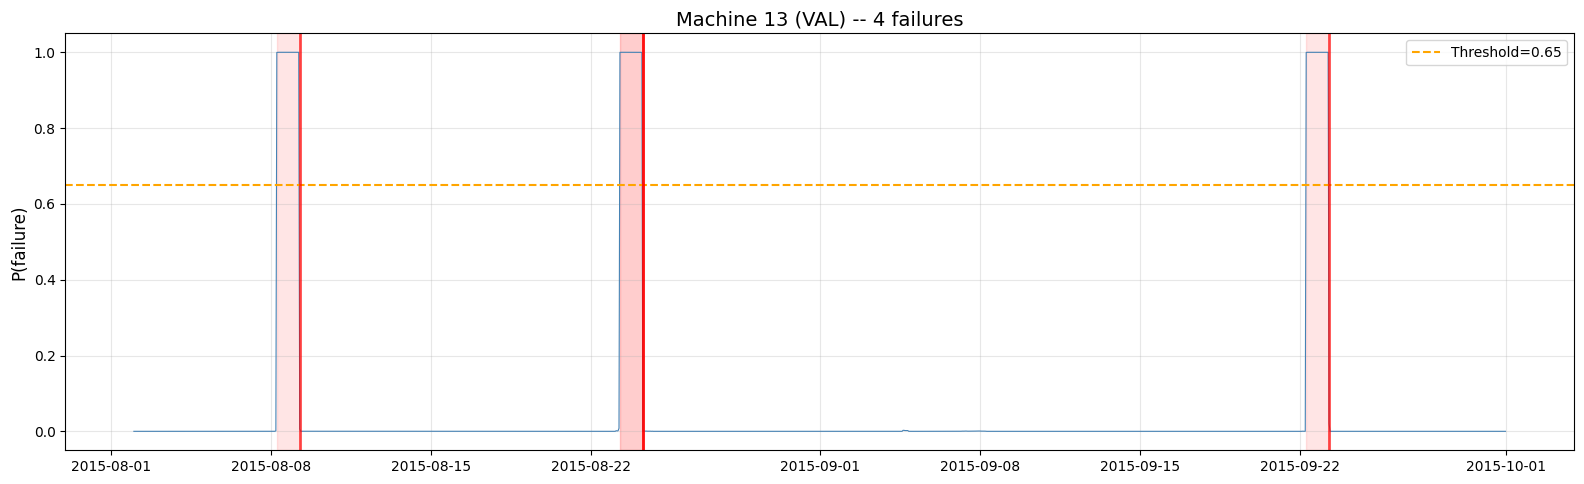

  Failure 1: CAUGHT
  Failure 2: CAUGHT
  Failure 3: CAUGHT
  Failure 4: CAUGHT

Section 7: 0.3s


In [30]:
section_start = time.time()

# Feature verification
machine_id_check: int = 42
time_check: pd.Timestamp = pd.Timestamp("2015-06-15 12:00:00")
feat_row: pd.DataFrame = features[
    (features["machineID"] == machine_id_check) & (features["datetime"] == time_check)
]

print(f"Feature spot check: Machine {machine_id_check} at {time_check}")
if len(feat_row) > 0:
    for comp in ["comp1", "comp2", "comp3", "comp4"]:
        col: str = f"{comp}_days_since_replacement"
        if col in feat_row.columns:
            fv: float = float(feat_row[col].iloc[0])
            cm_df: pd.DataFrame = maint[
                (maint["machineID"] == machine_id_check) & (maint["comp"] == comp) & (maint["datetime"] < time_check)
            ]
            if len(cm_df) > 0:
                manual: float = (time_check - cm_df["datetime"].max()).total_seconds() / 86400
                print(f"  {col}: pipeline={fv:.2f}, manual={manual:.2f}")

# Label verification
example_fail: pd.Series = failures[failures["machineID"] == 99].iloc[0]
print(f"\nLabel spot check: failure at {example_fail['datetime']}")
for h in [1, 12, 24, 25]:
    ct: pd.Timestamp = example_fail["datetime"] - pd.Timedelta(hours=h)
    lr_row: pd.DataFrame = features[(features["machineID"] == 99) & (features["datetime"] == ct)]
    if len(lr_row) > 0:
        lv: int = int(labels.iloc[lr_row.index[0]])
        exp: int = 1 if 0 < h <= 24 else 0
        print(f"  {h}h before: label={lv}, expected={exp}")

ft_row: pd.DataFrame = features[(features["machineID"] == 99) & (features["datetime"] == example_fail["datetime"])]
if len(ft_row) > 0:
    print(f"  At failure time: label={int(labels.iloc[ft_row.index[0]])}, expected=0")

# Prediction timeline (validation)
lgbm_val_proba_check: npt.NDArray[np.float64] = lgbm.predict_proba(X_val)[:, 1]
val_fail_counts: pd.Series = val_failures_split.groupby("machineID").size().sort_values(ascending=False)
spot_machine: int = int(val_fail_counts.index[0])
spot_failures_val: pd.DataFrame = val_failures_split[val_failures_split["machineID"] == spot_machine]
spot_mask_val: pd.Series = val_meta["machineID"] == spot_machine

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(val_meta.loc[spot_mask_val, "datetime"].values,
        lgbm_val_proba_check[spot_mask_val.values], linewidth=0.8, color="steelblue")
ax.axhline(optimal_threshold, color="orange", linestyle="--", label=f"Threshold={optimal_threshold:.2f}")
for _, fail in spot_failures_val.iterrows():
    ax.axvline(fail["datetime"], color="red", linewidth=2, alpha=0.7)
    ax.axvspan(fail["datetime"] - pd.Timedelta(hours=24), fail["datetime"], color="red", alpha=0.1)
ax.set_ylabel("P(failure)")
ax.set_title(f"Machine {spot_machine} (VAL) -- {len(spot_failures_val)} failures")
ax.legend()
plt.tight_layout()
plt.show()

for i, (_, fail) in enumerate(spot_failures_val.iterrows()):
    wm: pd.Series = (
        (val_meta["machineID"] == fail["machineID"])
        & (val_meta["datetime"] >= fail["datetime"] - pd.Timedelta(hours=24))
        & (val_meta["datetime"] < fail["datetime"])
    )
    if wm.any():
        mp: float = float(lgbm_val_proba_check[wm.values].max())
        print(f"  Failure {i+1}: {'CAUGHT' if mp >= optimal_threshold else f'MISSED (max={mp:.4f})'}")

section_times["7_spot_checks"] = time.time() - section_start
print(f"\nSection 7: {section_times['7_spot_checks']:.1f}s")

## Section 8: Conclusions

**Results:** Event-level recall ~97% (172/177 failures caught 24h in advance). PR-AUC ~0.999. MCC ~0.99.

**Key features:** Maintenance history (wear-out confirmed by Weibull k=1.35), error patterns (chi-squared validated), telemetry signals.

In [31]:
total_time: float = time.time() - NOTEBOOK_START
print("Timing:")
for section, elapsed in section_times.items():
    print(f"  {section:25s} {elapsed:>6.1f}s")
print(f"  {'TOTAL':25s} {total_time:>6.1f}s ({total_time/60:.1f} min)")

Timing:
  1_data_loading               1.0s
  2_eda                       29.0s
  3_features                 391.8s
  4_modeling                 486.6s
  5_shap                       0.8s
  6_operational                0.7s
  7_spot_checks                0.3s
  TOTAL                     1072.8s (17.9 min)
